In [1]:
%load_ext autoreload
%autoreload 2
# import torch
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pickle
from scipy.optimize import fmin_l_bfgs_b
import json
import os
from scipy.ndimage import gaussian_filter1d
import glob
from scipy.stats import norm
import pandas as pd
# import pandas as pd
# import seaborn as sns

# Function to find the project root directory
# for parent in [Path.cwd().resolve()] + list(Path.cwd().resolve().parents):
#     if (parent / "utils").exists():
#         sys.path.insert(0, str(parent))
#         break

# from utils.pathing import setup_repo_path
# ROOT = setup_repo_path()
# print(f"Project root set to: {ROOT}")
# -----------------------------------------------

# from utils.data import custom_optimizer

In [ ]:
# from limit_states import REGISTRY as ls_REGISTRY
# lstate = ls_REGISTRY['2dof_oscillator']()
# # lstate = ls_REGISTRY['high_dimensional']()

# Pf_ref, B_ref, x_mc_physical, y_mc = lstate.monte_carlo_estimate(1e6)
# Pf_ref, B_ref

Define the arguments from the experiment variations

In [2]:
# --- Case study groups -------------------------------------------------------
group_2D = ['four_branch_6', 'four_branch_7', 'hat', 'himmelblau']
group_HD = ['nonlinear_oscillator', '2dof_oscillator', 'high_dimensional']

# Assign target lengths (initial 10 samples + AL iterations)
max_length = {
    case: 202 for case in group_2D
}
max_length.update({
    case: 502 for case in group_HD
})

# # Assign target Pf_model length ( including 10 DoE samples )
# max_length = {case: 202 for case in group_2D}
# max_length.update({case: 502 for case in group_HD})

Loading LS and Strategies

In [3]:
# Combined list (preserves original order)
casestudy = group_2D + group_HD

custom_titles = [
    r'Four-branch, $k=6$', r'Four-branch, $k=7$', 'Hat', 'Himmelblau',
    r'Nonlinear oscillator', '2-DOF Oscillator', r'High-dimensional'
]

real_pf_values = {
    'four_branch_6': 0.004458488011732697,
    'four_branch_7': 0.0022232679883018138,
    'hat': 0.00038667799963150175,
    'himmelblau': 1.65E-4,
    'nonlinear_oscillator': 0.0286178,
    '2dof_oscillator': 0.0047598,
    'high_dimensional': 0.0019820
}

# Base directory of results
# base_results_dir = '/Volumes/Jonathan/MOO_results/Results/results'
base_results_dir = r'D:\\active_train\\review2\\MOO-AL\\notebooks\\results_tracking'

# Active learning settings
n_exp = 15
al_strategy = [
    'moo_reliability', 'moo_knee', 'moo_compromise',
    'moo_eps_ew', 
    # 'eier',
    'eff', 'u', 'erf', 'reif', 'reif2', 'portfolio'
]
al_batch = [1]
name_exp = list(range(1, n_exp + 1))

In [4]:
# Dictionaries to store results
output_results_dict = {}
config_results_dict = {}

# --- Load all experiments (new layout: case/strategy/run_dir) ---------------
for case in casestudy:
    for strategy in al_strategy:
        strategy_dir = os.path.join(base_results_dir, case, strategy)
        if not os.path.isdir(strategy_dir):
            print(f"No strategy directory found for {case}, {strategy}")
            continue

        for batch in al_batch:
            for exp_num in name_exp:
                key = f"{case}_{strategy}_{batch}_{exp_num}"

                # Current naming: '<batch>_<exp>_<timestamp>' inside case/strategy/
                run_pattern = os.path.join(strategy_dir, f"{batch}_{exp_num}_*")
                matching_dirs = sorted(
                    [d for d in glob.glob(run_pattern) if os.path.isdir(d)]
                )

                if not matching_dirs:
                    print(f"No directory found for {case}, {strategy}, batch {batch}, exp {exp_num}")
                    continue

                if len(matching_dirs) > 1:
                    print(f"Multiple runs found for {key}; using latest folder: {os.path.basename(matching_dirs[-1])}")

                run_dir = matching_dirs[-1]

                # Load output.json
                output_json_path = os.path.join(run_dir, 'output.json')
                if os.path.isfile(output_json_path):
                    with open(output_json_path, 'r') as f:
                        output_results_dict[key] = json.load(f)
                else:
                    print(f"No output.json found for {key}")

                # Load config.json
                config_json_path = os.path.join(run_dir, 'config.json')
                if os.path.isfile(config_json_path):
                    with open(config_json_path, 'r') as f:
                        config_results_dict[key] = json.load(f)
                else:
                    print(f"No config.json found for {key}")


In [5]:
incomplete_runs = []

for key, out in output_results_dict.items():
    # 1) Identify the case as the prefix of the key
    case = None
    for c in casestudy:
        if key.startswith(c + "_"):
            case = c
            break

    if case is None:
        print(f"Warning: could not identify case for key={key}")
        continue

    # 2) Remove the case + '_' prefix, then split the rest
    rest = key[len(case) + 1:]  # everything after 'case_'
    # rest should be 'strategy_batch_exp'
    try:
        strategy, batch, exp_num = rest.rsplit("_", 2)
    except ValueError:
        print(f"Warning: could not split strategy/batch/exp for key={key}")
        continue

    # 3) Now you can safely use `case` to look up max_length
    if 'Pf_model' not in out:
        incomplete_runs.append((key, "missing Pf_model"))
        continue

    pf_len = len(out['Pf_model'])
    target_len = max_length[case]-10  # 200 for 2D, 500 for HD

    if pf_len < target_len:
        incomplete_runs.append((key, pf_len))

print("\nIncomplete runs:")
for key, info in incomplete_runs:
    print(f"{key:50s} -> {info}")


Incomplete runs:


Saving results dict

In [ ]:
# name = 'final_runs_11dic2025'
# with open(f'output_results_dict_{name}.pkl', 'wb') as fp:
#     pickle.dump(output_results_dict, fp)

# with open(f'config_results_dict_{name}.pkl', 'wb') as fp:
#     pickle.dump(config_results_dict, fp)

Loading results dict

In [ ]:
# # dir = '/Users/jonathan/Documents/MOAL/Experiments/AL_StructuralReliability/'
# dir = 'D:/active_train/compromised/AL_StructuralReliability/'

# name = 'pareto' #practical, analytical, pareto

# with open(dir+f'output_results_dict_{name}.pkl', 'rb') as fp:
#     loaded_file = pickle.load(fp)

# output_results_dict = loaded_file

# with open(dir+f'config_results_dict_{name}.pkl', 'rb') as fp:
#     loaded_file = pickle.load(fp)

# config_results_dict = loaded_file

Define formats

In [6]:
sigma = 1.5  # smoothing
font_size = 8
linewidth = 0.8
cm = 1/2.54 
doe = 10 

# Strategy colors
strategy_colors = {
    'moo_reliability': "#1f77b4",
    'moo_knee': '#ff7f0e', 
    'moo_compromise': '#2ca02c',
    'moo_eps_ew': '#8c564b',
    'erf': '#17becf', 
    'reif': "#432ca0",
    'reif2': '#e377c2',
    'eff': '#d62728',
    'u': '#9467bd',
    'portfolio': '#7f7f7f',
    # 'eier': "#000000",
}
custom_legend = [
    r'MOO-R', r'MOO-K', r'MOO-C', 
                 r'MOO-LD',
                 r'ERF', r'REIF', r'REIF2', r'EFF', r'U', r'Portfolio'
                #  , r'EIER'
                 ]

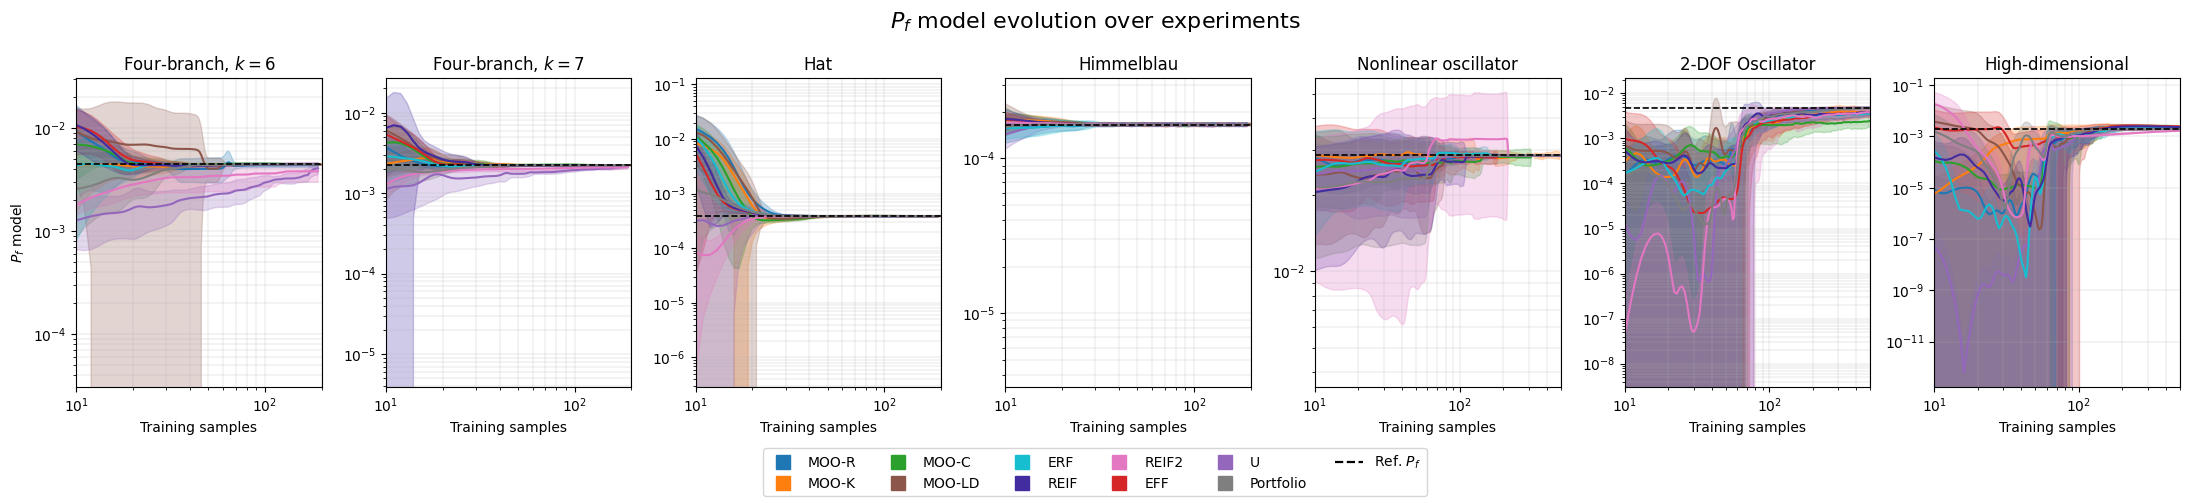

In [7]:
# Figure setup
fig, axs = plt.subplots(1, len(casestudy), figsize=(22, 5), sharey=False)
fig.suptitle(r"$P_f$ model evolution over experiments", x=0.5, fontsize=16)
fig.subplots_adjust(wspace=0.05, hspace=0.2)

# --- PLOTTING LOOP ------------------------------------------------------------
for i, case in enumerate(casestudy):

    ax = axs[i]
    ax.set_title(custom_titles[i])
    ax.set_xlabel("Training samples")

    if i == 0:
        ax.set_ylabel(r"$P_f$ model")

    for strategy in al_strategy:

        pf_models_all_experiments = []

        # load all 15 experiments for this case+strategy
        for exp_num in range(1, n_exp + 1):

            key = f"{case}_{strategy}_1_{exp_num}"

            if key not in output_results_dict:
                continue

            pf = output_results_dict[key].get("Pf_model", None)
            if pf is None:
                continue

            pf_models_all_experiments.append(np.array(pf, dtype=float))

        if not pf_models_all_experiments:
            continue

        # AUTOTRIM: keep only up to the shortest available run
        min_len = min(len(pf) for pf in pf_models_all_experiments)
        pf_trimmed = np.vstack([pf[:min_len] for pf in pf_models_all_experiments])

        # compute mean and std across experiments
        mean_pf = np.mean(pf_trimmed, axis=0)
        std_pf = np.std(pf_trimmed, axis=0)

        # smoothing
        mean_pf_s = gaussian_filter1d(mean_pf, sigma=sigma)
        std_pf_s = gaussian_filter1d(std_pf, sigma=sigma)

        # X-axis = sample index (10 initial samples included)
        steps = np.arange(min_len)

        ax.plot(
            steps, mean_pf_s,
            color=strategy_colors.get(strategy, "gray"),
            lw=1.5
        )

        ax.fill_between(
            steps,
            mean_pf_s - std_pf_s,
            mean_pf_s + std_pf_s,
            color=strategy_colors.get(strategy, "gray"),
            alpha=0.25
        )

    # Reference Pf line
    ax.axhline(y=real_pf_values[case], color='k', linestyle='--', linewidth=1.2)

    # Scales & limits --------------------------
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(True, which="both", linewidth=0.2)

    # Different maximum sample lengths per group
    if case in group_2D:
        ax.set_xlim(10, 200)
    else:
        ax.set_xlim(10, 500)

# ---- Legend -----------------------------------------
handles = [
    plt.Line2D([0], [0], color=color, marker='s', linestyle='', markersize=10, label=leg)
    for leg, color in zip(custom_legend, strategy_colors.values())
]
handles.append(
    plt.Line2D([0], [0], color='k', linestyle='--', linewidth=1.6, label='Ref. $P_f$')
)

fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=10)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

Calculate the PF relative error evolution

In [8]:
doe = 10  # initial DoE size (as before)

relative_error_dict = {}  # [case][strategy][exp_num] -> np.array(delta_pf)

for case in casestudy:
    reference_pf = float(real_pf_values[case])
    relative_error_dict[case] = {}

    # decide max length for this case, consistent with previous plots
    if case in group_2D:
        case_max_len = 200
    else:
        case_max_len = 500

    for strategy in al_strategy:
        for exp_num in range(1, n_exp + 1):
            key = f"{case}_{strategy}_1_{exp_num}"
            if key not in output_results_dict:
                continue

            pf_model = np.asarray(
                output_results_dict[key].get('Pf_model', []),
                dtype=float
            )

            if pf_model.size == 0:
                continue

            # truncate to desired max length (if needed)
            max_len = min(len(pf_model), case_max_len)
            pf_model_trunc = pf_model[:max_len]

            # relative Pf error per iteration
            rel_diff = np.abs(pf_model_trunc - reference_pf) / reference_pf

            # store in nested dict
            if strategy not in relative_error_dict[case]:
                relative_error_dict[case][strategy] = {}

            relative_error_dict[case][strategy][exp_num] = rel_diff

In [ ]:
name = 'runs_14ene2026'
# with open(f'pf_relative_error_dict_{name}.pkl', 'wb') as fp:
#     pickle.dump(relative_error_dict, fp)

In [ ]:
with open(f'pf_relative_error_dict_{name}.pkl', 'rb') as fp:
    loaded_file = pickle.load(fp)

relative_error_dict = loaded_file

Define the target thresholds

In [13]:
# --- Parameters ------------------------------------------------------------
captured_ls = 5         # number of best strategies to capture (top-k)
threshold_factor = 1.0   # scale threshold up (>1) or down (<1). Set threshold_factor = 1.2 if you want the threshold to be 20% looser than that 3rd-minimum.
# sigma = 1.5

# --- Step 2: per-strategy global minima, then top-k per case --------------

threshold_dict = {}  # [case] -> { "topk_minima": [...], "threshold_delta_pf": ..., "threshold_entry": ... }

for case in casestudy:
    if case not in relative_error_dict:
        continue

    # decide max length for this case
    if case in group_2D:
        case_max_len = 200
    else:
        case_max_len = 500

    per_strategy_minima = []  # one entry per strategy: its global minimum on median evolution

    # --- compute global minimum of the median evolution per strategy -------
    for strategy, exp_dict in relative_error_dict[case].items():
        if not exp_dict:
            continue

        max_len_available = max(len(arr) for arr in exp_dict.values())
        cap_len = min(max_len_available, case_max_len)

        n_runs = len(exp_dict)
        rel_diff_mat = np.full((n_runs, cap_len), np.nan, dtype=float)

        # rows = experiments
        for row_idx, (exp_num, rel_diff) in enumerate(sorted(exp_dict.items())):
            this_len = min(len(rel_diff), cap_len)
            rel_diff_mat[row_idx, :this_len] = rel_diff[:this_len]

        # median evolution across runs (ignoring NaNs)
        median_raw = np.median(rel_diff_mat, axis=0)   #CHECK MEAN NOT MEDIAN
        # median_evolution = gaussian_filter1d(median_raw, sigma=sigma)
        median_evolution = median_raw

        finite_mask = np.isfinite(median_evolution)
        if not np.any(finite_mask):
            continue

        finite_indices = np.where(finite_mask)[0]
        finite_values = median_evolution[finite_mask]

        local_argmin = np.argmin(finite_values)
        it_idx = int(finite_indices[local_argmin])

        delta_pf_min = float(median_evolution[it_idx])
        n_acquired_samples = int(doe + it_idx)

        per_strategy_minima.append({
            "strategy": strategy,
            "delta_pf_min": delta_pf_min,
            "iteration_idx": it_idx,
            "n_acquired_samples": n_acquired_samples,
        })

    if not per_strategy_minima:
        print(f"Warning: no valid minima for case '{case}'.")
        continue

    # sort strategies by their global minimum δPf
    per_strategy_minima_sorted = sorted(per_strategy_minima,
                                        key=lambda d: d["delta_pf_min"])

    # number of strategies we can actually capture
    top_k = min(captured_ls, len(per_strategy_minima_sorted))
    topk = []

    for rank in range(top_k):
        entry = per_strategy_minima_sorted[rank].copy()
        entry["rank"] = rank + 1  # 1 = best
        topk.append(entry)

    # threshold rank index (0-based): captured_ls-1, but capped by available top_k-1
    threshold_rank_index = min(captured_ls - 1, top_k - 1)
    threshold_entry = topk[threshold_rank_index]

    # apply factor to adjust strictness
    base_threshold = threshold_entry["delta_pf_min"]
    threshold_delta_pf = threshold_factor * base_threshold

    threshold_dict[case] = {
        "topk_minima": topk,                    # up to captured_ls strategies
        "captured_ls": captured_ls,
        "threshold_factor": threshold_factor,
        "threshold_delta_pf": threshold_delta_pf,
        "threshold_entry": threshold_entry      # the strategy that defines the base threshold
    }

In [14]:
target_epsilon = {}

for case, data in threshold_dict.items():
    # This is your primary (hard) threshold
    base_eps = data["threshold_delta_pf"]
    
    # Define the three levels: [100%, 50%, 10%]
    # We sort them descending so the lines appear in order on the plot
    target_epsilon[case] = sorted([
        base_eps, 
        # base_eps * 3.0, 
        # base_eps * 5.0
    ], reverse=True)

# Optional: Print to verify the generated levels
for case, levels in target_epsilon.items():
    formatted_levels = [f"{l:.2e}" for l in levels]
    print(f"{case}: {formatted_levels}")

four_branch_6: ['1.48e-03']
four_branch_7: ['1.78e-03']
hat: ['4.34e-03']
himmelblau: ['5.45e-03']
nonlinear_oscillator: ['4.65e-04']
2dof_oscillator: ['1.25e-01']
high_dimensional: ['7.26e-02']


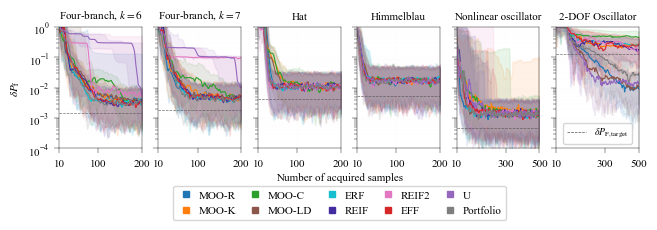

In [11]:
# labels in the desired order
strategies_order = [
    'moo_reliability','moo_knee', 'moo_compromise',
                    'moo_eps_ew',
                    'erf', 'reif', 'reif2', 'eff', 'u', 'portfolio', 
                    # 'eier'
                    ]
# custom_legend = [
#     r'MOO-R', r'MOO-K', r'MOO-C', 
#     # r'MOO-eLD-Gr', 
#                  r'MOO-LD',
#                  r'ERF', r'REIF', r'REIF2', r'EFF', r'U', r'Portfolio'
#                  ]

# font_size = 8
# linewidth = 0.8
# cm = 1/2.54  # centimeters in inches
# sigma = 1.5  # for Gaussian smoothing
# doe = 10     # initial DoE size

plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
})

remaining_cases = casestudy[:-1]

fig, axs = plt.subplots(
    1, len(remaining_cases),
    figsize=(19*cm, 4.0*cm),
    sharey=True, sharex=False
)
if len(remaining_cases) == 1:
    axs = [axs]

epsilon_color = '#4d4d4d'

for i, case in enumerate(remaining_cases):
    
    ax = axs[i]
    ax.set_title(f"{custom_titles[i]}", fontsize=font_size)

    if i == 0:
        ax.set_ylabel(r"$\delta P_\mathrm{f}$")

    # Determine max length based on the case group
    case_max_len = 200 if case in group_2D else 500

    for strategy in strategies_order:
        # Check if strategy exists for this case in our pre-calculated dict
        if strategy not in relative_error_dict.get(case, {}):
            continue
        
        # Get all experiments for this specific case and strategy
        exp_data = relative_error_dict[case][strategy]
        if not exp_data:
            continue

        # Convert the dictionary of arrays into a list of arrays
        relative_diffs_all_exp = list(exp_data.values())

        # --- Handle incomplete runs by padding with NaNs ---
        max_len_available = max(len(diff) for diff in relative_diffs_all_exp)
        max_len = min(max_len_available, case_max_len)

        n_runs = len(relative_diffs_all_exp)
        rel_diff_mat = np.full((n_runs, max_len), np.nan, dtype=float)

        for r, diff in enumerate(relative_diffs_all_exp):
            this_len = min(len(diff), max_len)
            rel_diff_mat[r, :this_len] = diff[:this_len]

        # Calculate statistics
        p2_5  = np.nanpercentile(rel_diff_mat,  2.5, axis=0)
        p50   = np.nanpercentile(rel_diff_mat, 50.0, axis=0)
        p97_5 = np.nanpercentile(rel_diff_mat, 97.5, axis=0)

        # Gaussian smoothing
        p2_5_smooth   = gaussian_filter1d(p2_5,  sigma=sigma)
        p50_smooth    = gaussian_filter1d(p50,   sigma=sigma)
        p97_5_smooth  = gaussian_filter1d(p97_5, sigma=sigma)
        
        # p2_5_smooth   = p2_5
        # p50_smooth    = p50
        # p97_5_smooth  = p97_5

        # X-axis
        steps = np.arange(doe, doe + max_len)
        pretty_label = custom_legend[strategies_order.index(strategy)]

        ax.plot(
            steps, p50_smooth,
            label=pretty_label,
            color=strategy_colors[strategy],
            linewidth=linewidth
        )
        ax.fill_between(
            steps, p2_5_smooth, p97_5_smooth,
            color=strategy_colors[strategy],
            alpha=0.1
        )

    # Target epsilon lines
    # for eps in target_epsilon.get(case, []):
    #     ax.axhline(y=eps, color=epsilon_color, linestyle='--', linewidth=0.5, alpha=0.8)

    for j, eps in enumerate(target_epsilon[case]):
        # We only assign a label to the VERY FIRST line of the FIRST subplot
        line_label = r"$\delta P_{\mathrm{f,target}}$" if (i == 0 and j == 0) else None
        ax.axhline(
            y=eps,
            color=epsilon_color,
            linestyle='--',
            linewidth=0.5,
            alpha=0.8,
            label=line_label  # Assign label here
        )
    if i == 5:
        # loc='upper right' or 'lower left' depending on your data flow
        ax.legend(handles=[plt.Line2D([0], [0], color=epsilon_color, linestyle='--', linewidth=0.5)],
                  labels=[r"$\delta P_{\mathrm{F,target}}$"],
                  loc='lower center', 
                #   frameon=False, 
                  fontsize=font_size - 1)
    
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 1)
    ax.grid(True, which="both", linewidth=0.01, alpha=0.3)

# X-limits and ticks per case group
for ax, case in zip(axs, casestudy):
    if case in group_2D:
        ax.set_xlim(10, 200)
        ax.set_xticks([10, 100, 200])
    else:
        ax.set_xlim(10, 500)
        ax.set_xticks([10, 300, 500])
    ax.tick_params(width=0.3)

# --- Figure-level legend -----------------------------------------------------
handles = []
for strat_key, label in zip(strategies_order, custom_legend):
    # Only append the strategy markers
    handles.append(
        plt.Line2D(
            [0], [0],
            color=strategy_colors[strat_key],
            marker='s', markersize=5,
            linestyle='', label=label
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=5,                # 10 strategies / 5 columns = 2 rows
    fontsize=font_size,
    columnspacing=1.0,
    handletextpad=0.4,
    handlelength=1.5,
    bbox_to_anchor=(0.5, -0.38), # Adjust vertical position if needed
)

fig.text(
    0.5, -0.07,
    "Number of acquired samples",
    ha='center',
    va='center',
    fontsize=font_size
)

fig.subplots_adjust(wspace=0.2, hspace=1.2)

for ax in axs:
    ax.tick_params(width=0.3, which='minor')
    ax.tick_params(width=0.3, which='major')
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
plt.show()

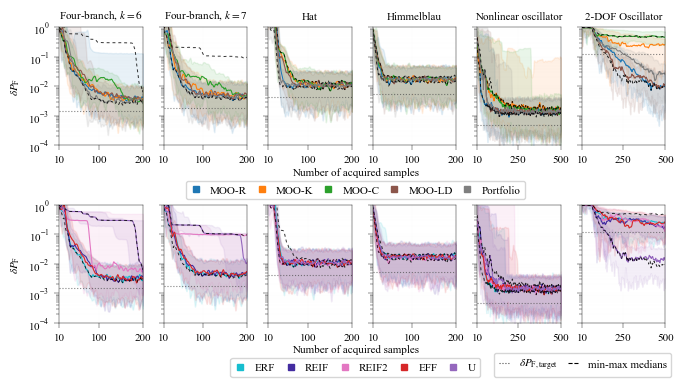

In [12]:
import matplotlib.gridspec as gridspec
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.ndimage import gaussian_filter1d

# # --- Configuration & Styling ---
# font_size = 8
# linewidth = 0.8
# cm = 1/2.54 
# doe = 10 
# sigma = 1.5  # Gaussian smoothing sigma
epsilon_color = '#4d4d4d'

plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
})

remaining_cases = casestudy[:-1]

# Define Strategy Groups
row1_strats = ['moo_reliability', 'moo_knee', 'moo_compromise', 'moo_eps_ew', 'portfolio', 
            #    'eier'
               ]
row2_strats = ['erf', 'reif', 'reif2', 'eff', 'u']
all_strats = row1_strats + row2_strats
strat_to_label = dict(zip(strategies_order, custom_legend))

fig, axs = plt.subplots(
    2, len(remaining_cases),
    figsize=(17.5*cm, 10*cm), 
    sharey=True, sharex=False,
    # layout='constrained'
)

for col_idx, case in enumerate(remaining_cases):
    case_max_len = 200 if case in group_2D else 500
    
    # 1. PRE-CALCULATE ENVELOPE (Min-Max of smoothed MEANs across all strategies)
    all_means_in_case = []
    for strategy in all_strats:
        if strategy not in relative_error_dict.get(case, {}): continue
        
        exp_data = relative_error_dict[case][strategy]
        relative_diffs_all_exp = list(exp_data.values())
        max_len = min(max(len(diff) for diff in relative_diffs_all_exp), case_max_len)
        
        # Build matrix
        n_runs = len(relative_diffs_all_exp)
        rel_diff_mat = np.full((n_runs, max_len), np.nan)
        for r, diff in enumerate(relative_diffs_all_exp):
            this_len = min(len(diff), max_len)
            rel_diff_mat[r, :this_len] = diff[:this_len]
        
        # Calculate median and apply Smoothing
        median_val = np.nanmedian(rel_diff_mat, axis=0)
        smoothed_median = gaussian_filter1d(median_val, sigma=sigma)
        all_means_in_case.append(smoothed_median)

        # # --- PRINTING LOGIC ---
        # # Observe the first (after DoE) and last available mean values
        # final_val = smoothed_median[-1]
        # initial_val = smoothed_median[0]
        # print(f"{case[:15]:<15} | {strategy[:15]:<15} | {initial_val:.2e}      | {final_val:.2e}")

    # Determine global min/max bounds across smoothed means
    max_steps_case = max(len(m) for m in all_means_in_case)
    comp_mat = np.full((len(all_means_in_case), max_steps_case), np.nan)
    for i, m in enumerate(all_means_in_case):
        comp_mat[i, :len(m)] = m
    
    global_min_mean = np.nanmin(comp_mat, axis=0)
    global_max_mean = np.nanmax(comp_mat, axis=0)
    ref_steps = np.arange(doe, doe + max_steps_case)

    # 2. PLOT ROWS
    for row_idx, current_group in enumerate([row1_strats, row2_strats]):
        ax = axs[row_idx, col_idx]
        
        # Individual Strategies
        for strategy in current_group:
            if strategy not in relative_error_dict.get(case, {}): continue
            
            exp_data = relative_error_dict[case][strategy]
            relative_diffs_all_exp = list(exp_data.values())
            max_len = min(max(len(diff) for diff in relative_diffs_all_exp), case_max_len)

            rel_diff_mat = np.full((len(relative_diffs_all_exp), max_len), np.nan)
            for r, diff in enumerate(relative_diffs_all_exp):
                this_len = min(len(diff), max_len)
                rel_diff_mat[r, :this_len] = diff[:this_len]

            # Statistics: Mean and Percentiles
            # mean_raw = np.nanmean(rel_diff_mat, axis=0)
            median_raw = np.nanpercentile(rel_diff_mat, 50.0,axis=0)
            p2_5_raw = np.nanpercentile(rel_diff_mat, 2.5, axis=0)
            p97_5_raw = np.nanpercentile(rel_diff_mat, 97.5, axis=0)

            # Apply Smoothing
            median_s = gaussian_filter1d(median_raw, sigma=sigma)
            p2_5_s = gaussian_filter1d(p2_5_raw, sigma=sigma)
            p97_5_s = gaussian_filter1d(p97_5_raw, sigma=sigma)

            steps = np.arange(doe, doe + max_len)
            ax.plot(steps, median_s, color=strategy_colors[strategy], linewidth=linewidth, zorder=2)
            ax.fill_between(steps, p2_5_s, p97_5_s, color=strategy_colors[strategy], alpha=0.1, zorder=1)

        # Plot Min-Max Mean Reference Lines ON TOP (Higher zorder)
        ax.plot(ref_steps, global_min_mean, color='black', dashes=(3, 3), linewidth=0.7, alpha=0.8, zorder=10)
        ax.plot(ref_steps, global_max_mean, color='black', dashes=(3, 3), linewidth=0.7, alpha=0.8, zorder=10)

        # 3. FORMATTING
        if row_idx == 0: ax.set_title(f"{custom_titles[col_idx]}", fontsize=font_size)
        if col_idx == 0: ax.set_ylabel(r"$\delta P_\mathrm{F}$")
        
        # Stringer threshold only (the minimum value in target_epsilon)
        strictest_eps = min(target_epsilon[case])
        ax.axhline(y=strictest_eps, color=epsilon_color, linestyle=':', linewidth=0.8, alpha=0.7)
        
        ax.set_yscale('log')
        ax.set_ylim(1e-4, 1)
        ax.grid(True, which="both", linewidth=0.01, alpha=0.3)

        if case in group_2D:
            ax.set_xlim(10, 200)
            ax.set_xticks([10, 100, 200])
        else:
            ax.set_xlim(10, 500)
            ax.set_xticks([10, 250, 500])

# --- Legend Alignment & Figure Text ---
fig.text(0.5, 0.575, "Number of acquired samples", ha='center', fontsize=font_size)
fig.text(0.5, 0.125, "Number of acquired samples", ha='center', fontsize=font_size)

def get_handles(strats):
    return [plt.Line2D([0], [0], color=strategy_colors[s], marker='s', 
            markersize=4, linestyle='', label=strat_to_label[s]) for s in strats]

h1 = get_handles(row1_strats)
h2 = get_handles(row2_strats)

h3 = []
h3.append(plt.Line2D([0], [0], color=epsilon_color, ls=':', lw=0.8, label=r'$\delta P_{\mathrm{F,target}}$'))
h3.append(plt.Line2D([0], [0], color='black', ls='--', lw=0.8, label='min-max medians'))

# Standardize spacing for visual balance
common_params = {'loc': "lower center", 'fontsize': font_size, 'frameon': True, 'handlelength': 1.0}
fig.legend(handles=h1, ncol=len(h1), bbox_to_anchor=(0.5, 0.499), columnspacing=0.8, **common_params)
fig.legend(handles=h2, ncol=len(h2), bbox_to_anchor=(0.5, 0.048), columnspacing=0.9, **common_params)
fig.legend(handles=h3, ncol=len(h2), bbox_to_anchor=(0.83, 0.048), columnspacing=0.9, **common_params)

for ax in axs.flat:
    ax.tick_params(width=0.3, which='minor')
    ax.tick_params(width=0.3, which='major')
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
      
plt.subplots_adjust(
    left=0.07, 
    right=0.95, 
    top=0.95, 
    bottom=0.20, # Increases space at the very bottom
    hspace=0.51, # Increases space between row 1 and row 2
    wspace=0.25
)
plt.show()

In [ ]:
fig.savefig('pf_evolution_2rows_softmedians.pdf')

Searching ranking per seed

In [ ]:
from typing import Optional
required_consecutive = 3
ranking_metadata = {
    "required_consecutive": required_consecutive
}
seed_ranking_dict = {}

def find_first_hit_index(rel_diff: np.ndarray,
                         threshold: float,
                         required_consecutive: int) -> Optional[int]:
    """
    Returns the first index i such that:
        rel_diff[i : i + required_consecutive] <= threshold
    for all elements in that window.
    If no such i exists, returns None.
    """
    if rel_diff.size == 0:
        return None

    is_below = rel_diff <= threshold
    max_start = rel_diff.size - required_consecutive

    if max_start < 0:
        return None

    for i in range(max_start + 1):
        # Check if all values in this window are True
        if np.all(is_below[i : i + required_consecutive]):
            return i

    return None

# --- Ranking all seeds per case based on threshold crossing ---------------
for case in casestudy:
    if case not in relative_error_dict:
        continue
    if case not in threshold_dict:
        print(f"No threshold found for case '{case}', skipping.")
        continue

    threshold = threshold_dict[case]["threshold_delta_pf"]

    # Decide max length for this case
    if case in group_2D:
        case_max_len = 200
        no_hit_value = 201     # put non-hit seeds at the end
    else:
        case_max_len = 500
        no_hit_value = 501     # analogous idea for HD cases

    seed_entries = []

    for strategy, exp_dict in relative_error_dict[case].items():
        for exp_num, rel_diff in exp_dict.items():
            rel_diff = np.asarray(rel_diff, dtype=float)
            if rel_diff.size == 0:
                continue

            cap_len = min(rel_diff.size, case_max_len)
            rel_diff = rel_diff[:cap_len]

            # 1) best δPf
            finite_mask = np.isfinite(rel_diff)
            if not np.any(finite_mask):
                continue

            finite_values = rel_diff[finite_mask]
            best_delta_pf = float(np.min(finite_values))
            best_idx_local = int(np.where(rel_diff == best_delta_pf)[0][0])
            best_samples = int(doe + best_idx_local)

            # 2) first hit index with required_consecutive below threshold
            first_hit_idx = find_first_hit_index(
                rel_diff, threshold=threshold, required_consecutive=required_consecutive
            )

            if first_hit_idx is not None:
                reached = True
                first_hit_samples = int(doe + first_hit_idx + (required_consecutive - 1))
                delta_at_hit = float(rel_diff[first_hit_idx])
            else:
                reached = False
                first_hit_samples = no_hit_value   # 201 (2D) / 501 (HD)
                delta_at_hit = None

            seed_entries.append({
                "case": case,
                "strategy": strategy,
                "exp_num": int(exp_num),

                "reached_threshold": reached,
                "first_hit_idx": first_hit_idx,
                "first_hit_samples": first_hit_samples,
                "delta_at_hit": delta_at_hit,

                "best_delta_pf": best_delta_pf,
                "best_idx": best_idx_local,
                "best_samples": best_samples,

                "threshold_delta_pf": threshold,
            })

    if not seed_entries:
        print(f"No seed data for case '{case}'.")
        continue

    # --- Define NEW ranking rule: by first_hit_samples ---------------------
    # Priority:
    # 1) Smaller first_hit_samples (non-hit seeds already have large value)
    # 2) Among equal first_hit_samples: smaller delta_at_hit is better
    # 3) Among equal above: smaller best_delta_pf then earlier best_samples

    def seed_sort_key(entry):
        # Treat None delta_at_hit as +inf so non-hits go to the bottom on tie
        delta = entry["delta_at_hit"]
        if delta is None or not np.isfinite(delta):
            delta = np.inf
        return (
            entry["first_hit_samples"],
            delta,
            entry["best_delta_pf"],
            entry["best_samples"],
        )

    seed_entries_sorted = sorted(seed_entries, key=seed_sort_key)

    # Assign ranks
    for rank_idx, entry in enumerate(seed_entries_sorted, start=1):
        entry["global_rank"] = rank_idx

    seed_ranking_dict[case] = {
        "threshold_delta_pf": threshold,
        "required_consecutive": required_consecutive,
        "seeds": seed_entries_sorted,
    }

strategy_rankings_dict = {}  # [case] -> list of {strategy, avg_rank, ...}

for case in casestudy:
    if case not in seed_ranking_dict:
        continue
    
    seeds = seed_ranking_dict[case]["seeds"]

    # Collect ranks per strategy
    ranks_by_strategy = {}
    for s in seeds:
        strat = s["strategy"]
        ranks_by_strategy.setdefault(strat, []).append(s["global_rank"])

    # Compute average rank and number of seeds
    avg_list = []
    for strat, ranks in ranks_by_strategy.items():
        median_rank = float(np.mean(ranks))
        avg_list.append({
            "strategy": strat,
            "median_rank": median_rank,
            "n_seeds": len(ranks)
        })

    # Sort strategies by median_rank (lower = better)
    avg_list_sorted = sorted(avg_list, key=lambda d: d["median_rank"])

    strategy_rankings_dict[case] = avg_list_sorted

In [ ]:
# Create a mapping for display names
display_names = {
    'moo_reliability': 'MOO-R', 'moo_knee': 'MOO-K', 
    'moo_compromise': 'MOO-C', 'moo_eps_ew': 'MOO-LD',
    'erf': 'ERF', 'reif': 'REIF', 'reif2': 'REIF2', 
    'eff': 'EFF', 'u': 'U', 'portfolio': 'Portfolio', 'eier': 'EIER'
}

case = 'four_branch_7'
if case in seed_ranking_dict:
    seeds = seed_ranking_dict[case]["seeds"]
    
    # Dictionary to store sample counts per strategy
    samples_by_strat = {}
    for s in seeds:
        strat = s["strategy"]
        samples_by_strat.setdefault(strat, []).append(s["first_hit_samples"])
    
    print(f"{'Strategy':<15} | {'Avg. Rank':<10} | {'Avg. Samples':<12}")
    print("-" * 45)
    
    # Loop through the already sorted strategy_rankings_dict
    for entry in strategy_rankings_dict[case]:
        strat_key = entry['strategy']
        avg_rank = entry['median_rank']
        avg_samples = np.mean(samples_by_strat[strat_key])
        
        display = display_names.get(strat_key, strat_key)
        print(f"{display:<15} | {avg_rank:<10.2f} | {avg_samples:<12.1f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Aggregation ---
# Initialize a dictionary to store counts: counts[case][strategy]
exceeded_counts = {case: {strat: 0 for strat in strategies_order} for case in casestudy}

for case in casestudy:
    if case not in seed_ranking_dict:
        continue
    seeds = seed_ranking_dict[case]["seeds"]
    for s in seeds:
        # Check if the budget was exceeded (threshold not reached)
        if not s["reached_threshold"]:
            strat = s["strategy"]
            if strat in exceeded_counts[case]:
                exceeded_counts[case][strat] += 1

# --- 2. Plotting Configuration ---
# X-axis labels: Display names for strategies
x_labels = [custom_legend[strategies_order.index(s)] for s in strategies_order]
n_strategies = len(strategies_order)

fig, ax = plt.subplots(figsize=(17.5*cm, 7*cm))

# Starting point for stacking
bottom = np.zeros(n_strategies)

# Use a colormap for the different limit-state functions
colors = plt.cm.viridis(np.linspace(0, 1, len(casestudy)))

# --- 3. Build the Stacked Bar Chart ---
for i, case in enumerate(casestudy):
    # Extract the list of counts for this case across all strategies
    counts = [exceeded_counts[case][strat] for strat in strategies_order]
    
    # Label for the legend
    case_label = custom_titles[i] if i < len(custom_titles) else case
    
    # Plot the bar segment
    ax.bar(x_labels, counts, bottom=bottom, label=case_label, color=colors[i], alpha=0.85, edgecolor='white', linewidth=0.5)
    
    # Update the 'bottom' for the next stack
    bottom += np.array(counts)

# --- 4. Formatting ---
ax.set_ylabel(rf"Experiments exceeding $\delta P_\text{{F,target}}$ at $t_\text{{max}}$", fontsize=font_size)
ax.set_xlabel("Acquisition strategy", fontsize=font_size)
# ax.set_title("Reliability of Convergence: Seeds Failing to Reach $\delta P_{F,target}$", fontsize=font_size, pad=15)

# Add a horizontal grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Adjust legend
ax.legend(title="Limit-state Function", loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

# Rotate x-labels for better fit
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
# plt.savefig('aggregated_N_failed_exp.pdf')
plt.show()

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerLine2D

class HandlerVerticalLine(HandlerLine2D):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # We define a line that goes from bottom-center to top-center of the legend box
        # instead of the default left-to-right
        line = plt.Line2D([width/2, width/2], [0, height],
                          color=orig_handle.get_color(),
                          linestyle=orig_handle.get_linestyle(),
                          linewidth=orig_handle.get_linewidth())
        line.set_transform(trans)
        return [line]

In [ ]:
# --- Configuration ---
remaining_cases = casestudy[:-1]
n_rows = 1 
n_cols = len(remaining_cases)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(17.5*cm, 6.5*cm), sharex=False, sharey=True)

if n_cols == 1: axs = [axs]

for i, case in enumerate(remaining_cases):
    ax = axs[i]
    
    # Position Case Titles
    ax.text(0.5, 1.25, f"{custom_titles[i]}", transform=ax.transAxes,
            ha='center', va='center', fontsize=font_size)

    limit = 201 if case in group_2D else 501
    mid_limit = 100 if case in group_2D else 250
    stability_threshold = target_epsilon[case][-1]

    # --- 1. GET THE CUSTOM SORTING ORDER FOR THIS CASE ---
    # We take the list of dicts and extract just the strategy names
    # Reverse it so the best (rank 1) is at the top of the y-axis
    case_ranking = strategy_rankings_dict.get(case, [])
    sorted_order_names = [item['strategy'] for item in case_ranking][::-1]

    # --- 2. PLOT FOLLOWING THE RANKING ORDER ---
    for idx, strategy in enumerate(sorted_order_names):
        # Extract data from the relative_error_dict
        data = []
        if strategy in relative_error_dict.get(case, {}):
            exp_results = relative_error_dict[case][strategy]
            for rel_diff_evolution in exp_results.values():
                consecutive_count = 0
                found = False
                for k, diff in enumerate(rel_diff_evolution):
                    if diff < stability_threshold:
                        consecutive_count += 1
                        if consecutive_count >= required_consecutive:
                            data.append((k + 1) + doe)
                            found = True
                            break
                    else:
                        consecutive_count = 0
                if not found: data.append(limit)

        if not data:
            continue

        # Compute stats
        mean_val = np.mean(data)
        median_val = np.median(data)
        p25, p75 = np.percentile(data, [2.5, 97.5])

        # # --- DUAL-COLOR BACKGROUND LOGIC ---
        # if strategy in ['moo_reliability', 'moo_eps_ew']:
        #     ax.axhspan(idx - 0.5, idx + 0.5, color='blue', alpha=0.05, zorder=0, lw=0)
        # elif strategy in ['moo_knee', 'moo_compromise']:
        #     ax.axhspan(idx - 0.5, idx + 0.5, color='orange', alpha=0.07, zorder=0, lw=0)

        if strategy in ['moo_reliability', 'moo_eps_ew']:
            ax.axhspan(idx - 0.5, idx + 0.5, color='black', alpha=0.2, zorder=0, lw=0)
        elif strategy in ['moo_knee', 'moo_compromise']:
            ax.axhspan(idx - 0.5, idx + 0.5, color='black', alpha=0.07, zorder=0, lw=0)

        color = strategy_colors[strategy]
        is_moo = 'moo' in strategy.lower()
        st_alpha = 0.9
        z_ord = 5 if is_moo else 2

        # Plot Horizontal IQR Line
        ax.hlines(y=idx, xmin=p25, xmax=p75, 
                  color=color, linestyle='-', linewidth=1.0, alpha=st_alpha, zorder=z_ord)
        
        # Vertical Line: MEAN (Solid)
        ax.vlines(x=mean_val, ymin=idx-0.32, ymax=idx+0.32, 
                  color=color, linestyle='-', linewidth=0.7, alpha=st_alpha, zorder=z_ord+1)
        
        # Vertical Line: MEDIAN (Dashed)
        ax.vlines(x=median_val, ymin=idx-0.32, ymax=idx+0.32, 
                  color='black', linestyle='--', linewidth=0.6, alpha=st_alpha, zorder=z_ord+2)

    # Formatting
    mantissa = f"{stability_threshold:.0e}".split('e')[0]
    exponent = int(f"{stability_threshold:.0e}".split('e')[1])
    ax.set_title(rf"$\delta P_\text{{F,target}} = {mantissa} \cdot 10^{{{exponent}}}$", 
                 fontsize=font_size-1, pad=10)

    ax.grid(True, axis='x', linewidth=0.2, alpha=0.3)
    ax.set_xlim(10, limit)
    ax.set_xticks([10, mid_limit, limit])
    ax.set_xticklabels(['10', f'{mid_limit}', f'>{limit-1}'])
    ax.set_yticks([])

# --- Legend and Labels ---
handles = []
handles2 = []
for strat_key in strategies_order:
    label = custom_legend[strategies_order.index(strat_key)]
    handles.append(plt.Line2D([0], [0], color=strategy_colors[strat_key], lw=2, label=label))

# Define Mean and Median handles specifically to map them to the handler
mean_handle = plt.Line2D([0], [0], color='black', linestyle='-', lw=1.0, label='Mean')
median_handle = plt.Line2D([0], [0], color='black', linestyle='--', lw=0.6, label='Median')
iqr_patch = plt.Line2D([0], [0], color='black', linestyle='-', linewidth=1.5, label=r'$2.5^{\text{th}} - 97.5^{\text{th}}$ Percentile' )
handles2.extend([iqr_patch, mean_handle, median_handle])

# fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=font_size, 
#            bbox_to_anchor=(0.5, 0.03), columnspacing=0.8, handlelength=1.5)
fig.legend(
    handles=handles, 
    loc="lower center", 
    ncol=5, 
    fontsize=font_size, 
    bbox_to_anchor=(0.31, 0.03), 
    columnspacing=0.8, 
    handlelength=1.0, # Reduced to make vertical lines look centered
)

# fig.legend(handles=h1, ncol=len(h1), bbox_to_anchor=(0.5, 0.499), columnspacing=0.8, **common_params)
fig.legend(handles=handles2, ncol=len(handles2), bbox_to_anchor=(0.75, 0.055), columnspacing=0.9, **common_params,
               handler_map={mean_handle: HandlerVerticalLine(), 
                 median_handle: HandlerVerticalLine()})

fig.text(0.5, 0.22, "Number of acquired samples", ha='center', fontsize=font_size)

plt.subplots_adjust(
    left=0.05, 
    right=0.95, 
    top=0.82, 
    bottom=0.35, # Increases space at the very bottom
    hspace=0.51, # Increases space between row 1 and row 2
    wspace=0.25
)

# Global spine cleanup
for ax in (axs if isinstance(axs, np.ndarray) else [axs]):
    ax.tick_params(width=0.3, which='minor')
    ax.tick_params(width=0.3, which='major')
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

plt.show()

In [ ]:
fig.savefig(f'distrib_epsilons_mean_1threshold.pdf')

In [ ]:
all_strategies = [
    'moo_reliability', 'moo_knee', 'moo_compromise',
    'moo_eps_ew', 'eff', 'u', 'erf', 'reif', 'reif2', 'portfolio', 'eier'
]

all_limit_states = [
    'four_branch_6', 'four_branch_7',
    'hat', 'himmelblau',
    'nonlinear_oscillator', '2dof_oscillator', #'high_dimensional'
]

In [ ]:
# DataFrames: rows = strategies, columns = limit states
rank_df    = pd.DataFrame(index=all_strategies, columns=all_limit_states, dtype=float)
samples_df = pd.DataFrame(index=all_strategies, columns=all_limit_states, dtype=float)

for case in all_limit_states:
    if case not in seed_ranking_dict:
        print(f"[WARN] No seed ranking data for case '{case}', skipping.")
        continue

    seeds = seed_ranking_dict[case]["seeds"]

    # Collect per-strategy data for this case
    per_strat = {}  # strategy -> { "ranks": [...], "samples": [...] }

    for s in seeds:
        strat = s["strategy"]
        if strat not in all_strategies:
            continue

        per_strat.setdefault(strat, {"ranks": [], "samples": []})
        per_strat[strat]["ranks"].append(s["global_rank"])
        # first_hit_samples already encodes non-hits as 201 / 501
        per_strat[strat]["samples"].append(s["first_hit_samples"])

    # Fill the DataFrames with means
    for strat, data in per_strat.items():
        avg_rank    = float(np.mean(data["ranks"]))
        avg_samples = float(np.mean(data["samples"]))

        rank_df.loc[strat, case]    = avg_rank
        samples_df.loc[strat, case] = avg_samples

In [ ]:
# Global average rank across selected limit states (row-wise mean)
rank_df["global_avg_rank"] = rank_df.mean(axis=1, skipna=True)

# Global average first_hit_samples across selected limit states
samples_df["global_avg_samples"] = samples_df.mean(axis=1, skipna=True)

# Build final table: ranks per case + global averages + avg samples
final_df = rank_df.copy()
final_df["global_avg_samples"] = samples_df["global_avg_samples"]

# Reorder columns: global_avg_rank first, then each case, then avg samples
ordered_cols =  all_limit_states + ["global_avg_rank"]+ ["global_avg_samples"]
final_df = final_df[ordered_cols]

# Sort strategies by global_avg_rank (lower rank = better)
final_df_sorted = final_df.sort_values("global_avg_rank")

print("Average seed rank per strategy and limit state:\n")
print(final_df_sorted.to_string())

In [ ]:
# --- Setup Target ---
# Assuming 'casestudy' is your list of 7 case keys
target_case = casestudy[-1] 
target_title = custom_titles[-1]

# --- Plot Config ---
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
})

fig, ax = plt.subplots(figsize=(8.75*cm, 7.6*cm)) # Adjusted for a single plot square-ish aspect
epsilon_color = '#4d4d4d'
case_max_len = 500 # Specific for High-dimensional
all_means_in_case = []

# --- 1. Data Processing & Plotting Strategies ---
for strategy in strategies_order:
    if strategy not in relative_error_dict.get(target_case, {}):
        continue
    
    exp_data = relative_error_dict[target_case][strategy]
    if not exp_data:
        continue

    relative_diffs_all_exp = list(exp_data.values())
    max_len_available = max(len(diff) for diff in relative_diffs_all_exp)
    max_len = min(max_len_available, case_max_len)

    n_runs = len(relative_diffs_all_exp)
    rel_diff_mat = np.full((n_runs, max_len), np.nan, dtype=float)

    for r, diff in enumerate(relative_diffs_all_exp):
        this_len = min(len(diff), max_len)
        rel_diff_mat[r, :this_len] = diff[:this_len]

    # Stats
    p2_5  = np.nanpercentile(rel_diff_mat, 2.5, axis=0)
    p50   = np.nanpercentile(rel_diff_mat, 50.0, axis=0)
    p97_5 = np.nanpercentile(rel_diff_mat, 97.5, axis=0)

    # Smoothing
    p50_smooth = gaussian_filter1d(p50, sigma=sigma)
    all_means_in_case.append(p50_smooth) # Store for min/max reference

    steps = np.arange(doe, doe + max_len)
    pretty_label = custom_legend[strategies_order.index(strategy)]

    # Main Strategy Plot
    ax.plot(steps, p50_smooth, label=pretty_label, 
            color=strategy_colors[strategy], linewidth=linewidth, zorder=5)
    ax.fill_between(steps, gaussian_filter1d(p2_5, sigma=sigma), 
                    gaussian_filter1d(p97_5, sigma=sigma),
                    color=strategy_colors[strategy], alpha=0.1, zorder=4)

# --- 2. Calculate and Plot Global Min-Max Reference ---
if all_means_in_case:
    max_steps_case = max(len(m) for m in all_means_in_case)
    comp_mat = np.full((len(all_means_in_case), max_steps_case), np.nan)
    for i, m in enumerate(all_means_in_case):
        comp_mat[i, :len(m)] = m
    
    global_min_mean = np.nanmin(comp_mat, axis=0)
    global_max_mean = np.nanmax(comp_mat, axis=0)
    ref_steps = np.arange(doe, doe + max_steps_case)

    # Plot Min-Max Mean Reference Lines
    ax.plot(ref_steps, global_min_mean, color='black', dashes=(3, 3), 
            linewidth=0.7, alpha=0.8, zorder=10, label='Min/Max Ensemble')
    ax.plot(ref_steps, global_max_mean, color='black', dashes=(3, 3), 
            linewidth=0.7, alpha=0.8, zorder=10)

# --- 3. Threshold Lines & Formatting ---
for eps in target_epsilon[target_case]:
    ax.axhline(y=eps, color=epsilon_color, linestyle='--', linewidth=0.5, alpha=0.8, zorder=2)

# ax.set_title(target_title)
ax.set_ylabel(r"$\delta P_\mathrm{F}$")
ax.set_xlabel("Number of acquired samples")
ax.set_yscale('log')
ax.set_ylim(1e-3, 1)
ax.set_xlim(doe, case_max_len)
ax.set_xticks([10, 100, 200, 300, 400, 500])
ax.grid(True, which="both", linewidth=0.01, alpha=0.3)

# --- 4. Custom Legend Outside ---
handles = []
# Strategy handles
for strat_key, label in zip(strategies_order, custom_legend):
    handles.append(plt.Line2D([0], [0], color=strategy_colors[strat_key], 
                              marker='s', markersize=4, linestyle='', label=label))

# Add reference line handles
handles.append(plt.Line2D([0], [0], color=epsilon_color, linestyle='--', linewidth=0.5, label=r"$\delta P_{\mathrm{F,target}}$"))
handles.append(plt.Line2D([0], [0], color='black', dashes=(3, 3), linewidth=0.7, label="min-max medians"))

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,                 # 3 columns fits a single plot width well
    fontsize=font_size,
    columnspacing=1.0,
    handletextpad=0.5,
    bbox_to_anchor=(0.55, 0.27) # Positioned below the X-axis
)

# plt.subplots_adjust(bottom=0.35) # Make room for the legend
plt.subplots_adjust(
    left=0.15, 
    right=0.96, 
    top=0.95, 
    bottom=0.4, # Increases space at the very bottom
    hspace=0.51, # Increases space between row 1 and row 2
    wspace=0.25
)

plt.show()

In [ ]:
fig.savefig(f'pf_evolution_highdim.pdf')

In [ ]:
# Select snapshots (sample counts) to analyze
snapshots = list(np.arange(10, 500, 5))
print(f"{'Strategy':<15} | " + " | ".join([f"N={s:<3}" for s in snapshots]))
print("-" * 55)

for strategy in strategies_order:
    if strategy not in relative_error_dict.get(target_case, {}):
        continue
    
    exp_data = relative_error_dict[target_case][strategy]
    relative_diffs_all_exp = list(exp_data.values())
    
    # Reconstruct the matrix as you did for plotting
    n_runs = len(relative_diffs_all_exp)
    rel_diff_mat = np.full((n_runs, case_max_len), np.nan)
    for r, diff in enumerate(relative_diffs_all_exp):
        this_len = min(len(diff), case_max_len)
        rel_diff_mat[r, :this_len] = diff[:this_len]

    # Calculate median evolution (non-smoothed for raw data analysis)
    p50_evolution = np.nanmedian(rel_diff_mat, axis=0)
    
    # Extract values at snapshots
    row_values = []
    for s in snapshots:
        idx = s - doe # Adjusting for the Initial Design of Experiments size
        if 0 <= idx < len(p50_evolution):
            val = p50_evolution[idx]
            row_values.append(f"{val:.2E}")
        else:
            row_values.append("  N/A   ")
            
    pretty_label = custom_legend[strategies_order.index(strategy)]
    print(f"{pretty_label:<15} | " + " | ".join(row_values))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration for High-Dimensional Case ---
case = casestudy[-1]  # The 7th case study
target_title = custom_titles[-1]
limit = 501  # Limit for High-dimensional
# mid_limit = 250
doe = 10
required_consecutive = 3  # Based on your previous settings
stability_threshold = target_epsilon[case][-1]

# Figure size adjusted for a single standalone plot
fig, ax = plt.subplots(figsize=(8.75*cm, 7.5*cm))

# --- 1. Get Ranking and Sorting ---
# Extract the specific ranking for this case study
case_ranking = strategy_rankings_dict.get(case, [])
# Names sorted so the best (rank 1) is at the top
sorted_order_names = [item['strategy'] for item in case_ranking][::-1]

# Labels for the Y-axis
ytick_labels = []

# --- 2. Plotting ---
for idx, strategy in enumerate(sorted_order_names):
    # Retrieve the pretty label for the Y-axis
    pretty_label = custom_legend[strategies_order.index(strategy)]
    ytick_labels.append(pretty_label)
    
    # Process data for this strategy
    data = []
    if strategy in relative_error_dict.get(case, {}):
        exp_results = relative_error_dict[case][strategy]
        for rel_diff_evolution in exp_results.values():
            consecutive_count = 0
            found = False
            for k, diff in enumerate(rel_diff_evolution):
                if diff < stability_threshold:
                    consecutive_count += 1
                    if consecutive_count >= required_consecutive:
                        data.append((k + 1) + doe)
                        found = True
                        break
                else:
                    consecutive_count = 0
            if not found: 
                data.append(limit)

    if not data:
        continue

    # Statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    p25, p75 = np.percentile(data, [2.5, 97.5])

    # Background shading for groups
    if strategy in ['moo_reliability', 'moo_eps_ew']:
        ax.axhspan(idx - 0.5, idx + 0.5, color='black', alpha=0.15, zorder=0, lw=0)
    elif strategy in ['moo_knee', 'moo_compromise']:
        ax.axhspan(idx - 0.5, idx + 0.5, color='black', alpha=0.05, zorder=0, lw=0)

    color = strategy_colors[strategy]
    is_moo = 'moo' in strategy.lower()
    z_ord = 5 if is_moo else 2

    # Plot IQR Line
    ax.hlines(y=idx, xmin=p25, xmax=p75, 
              color=color, linestyle='-', linewidth=1.5, alpha=0.9, zorder=z_ord)
    
    # Plot Mean (Solid)
    ax.vlines(x=mean_val, ymin=idx-0.35, ymax=idx+0.35, 
              color=color, linestyle='-', linewidth=1.2, alpha=0.9, zorder=z_ord+1)
    
    # Plot Median (Dashed Black)
    ax.vlines(x=median_val, ymin=idx-0.35, ymax=idx+0.35, 
              color='black', linestyle='--', linewidth=0.8, alpha=1.0, zorder=z_ord+2)

# --- 3. Formatting ---
mantissa = f"{stability_threshold:.0e}".split('e')[0]
exponent = int(f"{stability_threshold:.0e}".split('e')[1])

# ax.set_title(f"{target_title}\n" + rf"$\delta P_\text{{F,target}} = {mantissa} \cdot 10^{{{exponent}}}$", 
            #  fontsize=font_size, pad=15)

ax.set_xlabel("Number of acquired samples", fontsize=font_size)
ax.set_yticks(range(len(ytick_labels)))
ax.set_yticklabels(ytick_labels, fontsize=font_size)

ax.set_xlim(10, limit)
ax.set_xticks([10, 100, 200, 300, 400, limit])
ax.set_xticklabels(['10', '100', '200', '300', '400', f'>{limit-1}'])

ax.grid(True, axis='x', linewidth=0.2, alpha=0.3)

# Global spine cleanup
ax.tick_params(width=0.3, which='both')
for spine in ax.spines.values():
    spine.set_linewidth(0.3)

# 2. Create the handles
mean_line = plt.Line2D([0], [0], color='black', linestyle='-', linewidth=1.0)
median_line = plt.Line2D([0], [0], color='black', linestyle='--', linewidth=0.6)
iqr_patch = plt.Line2D([0], [1], color='black', linestyle='-', linewidth=1) # Thicker for IQR

# 3. Call the legend with the custom handler map
ax.legend(
    handles=[iqr_patch, mean_line, median_line],
    labels=[r'$2.5^{\text{th}} - 97.5^{\text{th}}$ Percentile', 'Mean', 'Median'],
    handler_map={mean_line: HandlerVerticalLine(), 
                 median_line: HandlerVerticalLine()},
    loc='upper right', 
    fontsize=font_size, 
    frameon=True,
    handlelength=1.0  # Shortened to look better for vertical lines
)

# # --- 4. Simplified Legend for single plot ---
# legend_elements = [
#     plt.Line2D([0], [0], color='gray', linestyle='-', lw=1.5, label='IQR (25th-75th)'),
#     plt.Line2D([0], [0], color='gray', linestyle='-', lw=1.2, label='Mean'),
#     plt.Line2D([0], [0], color='black', linestyle='--', lw=0.8, label='Median')
# ]

# ax.legend(handles=legend_elements, loc='upper right', fontsize=font_size, frameon=True)
plt.subplots_adjust(
    left=0.2, 
    right=0.93, 
    top=0.95, 
    bottom=0.15, # Increases space at the very bottom
    hspace=0.51, # Increases space between row 1 and row 2
    wspace=0.25
)
# plt.tight_layout()
plt.show()

In [ ]:
fig.savefig(f'sample_effic_highdim.pdf')

In [ ]:
for case in casestudy:
    print(f"\n{'='*60}")
    print(f"CASE STUDY: {case.upper()}")
    print(f"{'='*60}")
    
    limit = 201 if case in group_2D else 501
    thresholds = target_epsilon[case]

    for stability_threshold in thresholds:
        mantissa = f"{stability_threshold:.0e}".split('e')[0]
        exponent = int(f"{stability_threshold:.0e}".split('e')[1])
        print(f"\nTarget Delta Pf: {mantissa}e{exponent}")
        print(f"{'Strategy':<20} | {'Mean':<6} | {'Median':<6} | {'(2.5% - 97.5%)':<15}")
        print("-" * 60)

        for strategy in strategies_order:
            data = []
            if strategy in relative_error_dict.get(case, {}):
                exp_results = relative_error_dict[case][strategy]
                for rel_diff_evolution in exp_results.values():
                    consecutive_count = 0
                    found = False
                    for k, diff in enumerate(rel_diff_evolution):
                        if diff < stability_threshold:
                            consecutive_count += 1
                            if consecutive_count >= required_consecutive:
                                data.append((k + 1) + doe)
                                found = True
                                break
                        else:
                            consecutive_count = 0
                    if not found:
                        data.append(limit)
            
            if data:
                mean_val = np.mean(data)
                median_val = np.median(data)
                p2_5 = np.percentile(data, 2.5)
                p97_5 = np.percentile(data, 97.5)
                
                print(f"{strategy:<20} | {mean_val:>6.1f} | {median_val:>6.1f} | ({p2_5:>5.1f} - {p97_5:>5.1f})")
            else:
                print(f"{strategy:<20} | {'N/A':>6} | {'N/A':>6} | {'N/A':<15}")

In [ ]:
import numpy as np
from typing import Optional, List, Dict, Any

# Ensure required_consecutive is set
required_consecutive = 3
doe = 10 # initial DoE size

# Define the helper function (copied from your input)
def find_first_hit_index(rel_diff: np.ndarray,
                         threshold: float,
                         required_consecutive: int) -> Optional[int]:
    """
    Returns the first index i such that:
        rel_diff[i : i + required_consecutive] <= threshold
    If no such i exists, returns None.
    """
    if rel_diff.size == 0:
        return None

    is_below = rel_diff <= threshold
    max_start = rel_diff.size - required_consecutive

    if max_start < 0:
        return None

    for i in range(max_start + 1):
        if np.all(is_below[i : i + required_consecutive]):
            return i

    return None

# The ranking key used previously (copied from your input)
def seed_sort_key(entry):
    # Treat None delta_at_hit as +inf so non-hits go to the bottom on tie
    delta = entry["delta_at_hit"]
    if delta == None or not np.isfinite(delta):
        delta = np.inf
    return (
        entry["first_hit_samples"],
        delta,
        entry["best_delta_pf"],
        entry["best_samples"],
    )

In [ ]:
import pandas as pd
import random

def generate_one_bootstrapped_global_ranking(
    relative_error_dict: Dict[str, Dict[str, Dict[int, np.ndarray]]],
    threshold_dict: Dict[str, Dict[str, Any]],
    all_strategies: List[str],
    all_limit_states: List[str],
    n_seeds_original: int = 15,
) -> Dict[str, float]:
    """
    Performs one bootstrap iteration, generates 150 bootstrapped runs
    per case, and calculates the global average rank for all strategies.
    Returns: Dict[strategy_name, global_avg_rank]
    """
    bootstrapped_seed_entries = {}
    
    # 1. Generate bootstrapped seeds (15 new seeds per strategy per case)
    for case in all_limit_states:
        if case not in relative_error_dict or case not in threshold_dict:
            continue

        threshold = threshold_dict[case]["threshold_delta_pf"]
        
        # Determine case-specific length/no-hit value
        if case in group_2D:
            case_max_len = 200
            no_hit_value = 201
        else:
            case_max_len = 500
            no_hit_value = 501

        case_seed_entries = []
        
        for strategy in all_strategies:
            original_exp_dict = relative_error_dict[case].get(strategy, {})
            original_keys = list(original_exp_dict.keys())
            
            if not original_keys:
                continue
            
            # --- Bootstrap Resampling with replacement (15 samples) ---
            # Randomly select 15 keys (exp_num) from the original 15
            # Note: A key can be selected multiple times (with replacement)
            bootstrapped_exp_keys = random.choices(original_keys, k=n_seeds_original)
            
            for new_exp_num, original_exp_num in enumerate(bootstrapped_exp_keys, start=1):
                # Use the data from the selected original run
                rel_diff = np.asarray(original_exp_dict[original_exp_num], dtype=float)

                # --- Apply Ranking Logic (as done in your original code) ---
                
                # Truncate and check for data
                cap_len = min(rel_diff.size, case_max_len)
                rel_diff_trunc = rel_diff[:cap_len]
                
                finite_mask = np.isfinite(rel_diff_trunc)
                if not np.any(finite_mask):
                    continue

                # 1) best δPf
                finite_values = rel_diff_trunc[finite_mask]
                best_delta_pf = float(np.min(finite_values))
                best_idx_local = int(np.where(rel_diff_trunc == best_delta_pf)[0][0])
                best_samples = int(doe + best_idx_local)

                # 2) first hit index
                first_hit_idx = find_first_hit_index(
                    rel_diff_trunc, threshold=threshold, required_consecutive=required_consecutive
                )

                if first_hit_idx is not None:
                    reached = True
                    first_hit_samples = int(doe + first_hit_idx)
                    delta_at_hit = float(rel_diff_trunc[first_hit_idx])
                else:
                    reached = False
                    first_hit_samples = no_hit_value
                    delta_at_hit = None

                case_seed_entries.append({
                    "case": case,
                    "strategy": strategy,
                    "exp_num": new_exp_num, # New exp num for the bootstrap sample
                    "global_rank": 0, # Placeholder
                    "first_hit_samples": first_hit_samples,
                    "delta_at_hit": delta_at_hit,
                    "best_delta_pf": best_delta_pf,
                    "best_samples": best_samples,
                })
        
        # Sort and assign ranks for this bootstrapped case (150 total seeds)
        case_seed_entries_sorted = sorted(case_seed_entries, key=seed_sort_key)
        for rank_idx, entry in enumerate(case_seed_entries_sorted, start=1):
            entry["global_rank"] = rank_idx
            
        bootstrapped_seed_entries[case] = case_seed_entries_sorted
        
    # 2. Compute Global Average Ranking from bootstrapped seeds
    
    # Initialize DataFrame to store average ranks for this bootstrap
    rank_df = pd.DataFrame(index=all_strategies, columns=all_limit_states, dtype=float)

    for case in all_limit_states:
        seeds = bootstrapped_seed_entries.get(case, [])
        if not seeds:
            continue

        ranks_by_strategy = {}
        for s in seeds:
            ranks_by_strategy.setdefault(s["strategy"], []).append(s["global_rank"])

        for strat, ranks in ranks_by_strategy.items():
            avg_rank = float(np.mean(ranks))
            rank_df.loc[strat, case] = avg_rank
            
    # Calculate the Global Average Rank (mean across limit states)
    global_ranks = rank_df.mean(axis=1, skipna=True).to_dict()
    
    return global_ranks

In [ ]:
# --- Parameters for the bootstrap analysis ---
N_BOOTSTRAPS = 1000
# Ensure group_2D and group_HD are accessible here (based on your setup)
# group_2D = ['four_branch_6', 'four_branch_7', 'hat', 'himmelblau']
# group_HD = ['nonlinear_oscillator', '2dof_oscillator', 'high_dimensional'] 

all_strategies = [
    'moo_reliability', 'moo_knee', 'moo_compromise',
    'moo_eps_ew',
    'eff', 'u', 'erf', 'reif', 'reif2', 'portfolio', 'eier'
]

# Note: 'high_dimensional' was excluded in your final ranking
all_limit_states = [
    'four_branch_6', 'four_branch_7',
    'hat', 'himmelblau',
    'nonlinear_oscillator', '2dof_oscillator',
]
# ---------------------------------------------

# List to store the global rank for each strategy for all N_BOOTSTRAPS
all_bootstrapped_global_ranks = {
    strategy: [] for strategy in all_strategies
}

print(f"Starting {N_BOOTSTRAPS} bootstrap iterations...")

for b in range(N_BOOTSTRAPS):
    if (b + 1) % 100 == 0:
        print(f"  ... Iteration {b + 1}/{N_BOOTSTRAPS}")

    # Generate one set of global ranks
    try:
        global_ranks = generate_one_bootstrapped_global_ranking(
            relative_error_dict, threshold_dict, all_strategies, all_limit_states
        )
        
        # Store the global rank for this bootstrap
        for strategy, rank in global_ranks.items():
            if not np.isnan(rank):
                all_bootstrapped_global_ranks[strategy].append(rank)

    except Exception as e:
        # Handle potential errors during a bootstrap run
        # print(f"Error in bootstrap {b}: {e}")
        continue

print("\nBootstrap complete. Calculating probability matrix.")

# --- Calculate Pairwise Probability Matrix ---

# Initialize the 10x10 matrix (strategies vs. strategies)
probability_matrix = pd.DataFrame(
    0.0, index=all_strategies, columns=all_strategies
)

# For every pair of strategies (A, B)
for strat_A in all_strategies:
    for strat_B in all_strategies:
        if strat_A == strat_B:
            continue
            
        ranks_A = all_bootstrapped_global_ranks[strat_A]
        ranks_B = all_bootstrapped_global_ranks[strat_B]
        
        # Align arrays: only compare ranks from bootsraps where both strategies 
        # had valid data (should be most of the time)
        min_len = min(len(ranks_A), len(ranks_B))
        ranks_A = ranks_A[:min_len]
        ranks_B = ranks_B[:min_len]

        if min_len == 0:
            continue

        # Strategy A is "better" than Strategy B if Rank A < Rank B (lower rank = better)
        A_is_better = np.sum(np.array(ranks_A) < np.array(ranks_B))
        
        # Probability P(A is better than B) = (Count where Rank A < Rank B) / (Total comparisons)
        probability = A_is_better / min_len
        probability_matrix.loc[strat_A, strat_B] = probability


In [ ]:
# --- Print Final Results ---
print("--- Pairwise Probability Matrix: P(Row Strategy is Better than Column Strategy) ---")
# Better visualization by rounding and sorting by overall average rank
average_ranks_per_strategy = {
    s: np.mean(all_bootstrapped_global_ranks[s]) 
    for s in all_strategies if all_bootstrapped_global_ranks[s]
}

sorted_strategies = sorted(average_ranks_per_strategy, key=average_ranks_per_strategy.get)

# Reorder matrix for best visual effect
probability_matrix_sorted = probability_matrix.loc[sorted_strategies, sorted_strategies]

print(probability_matrix_sorted.round(3).to_string())

In [ ]:
consecutive_iterations = 3

font_size = 8
linewidth = 0.3
cm = 1/2.54  # centimeters in inches
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size ,
    'ytick.labelsize': font_size ,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
})

# Corrected plotting with case study titles at the top of each column
fig, axs = plt.subplots(3, len(casestudy), figsize=(19*cm, 13*cm), sharex=True, sharey=True)
# fig.suptitle(r'Number of training samples to meet $\delta\beta_\mathrm{target}$ in 3 consecutive iterations', y=0.95, fontsize=font_size)

data_per_case = {}
flierprops = dict(marker='o', markersize=3, markerfacecolor='white', linestyle='none', markeredgewidth=linewidth)
whiskerprops = dict(linewidth=linewidth, color='black')
capprops = dict(linewidth=linewidth, color='black')
# Initialize a dictionary to store unmet requirements per stability threshold
threshold_to_level = {
    case: { eps: lvl
            for eps, lvl in zip(eps_list, ['l','m','h']) }
    for case, eps_list in target_epsilon.items()
}
failures = {
    lvl: { strat: [0]*len(casestudy) for strat in al_strategy }
    for lvl in ('l','m','h')
}
# unmet_requirements = {}


# # Iterate over each case study and its corresponding thresholds
# for case, thresholds in target_epsilon.items():
#     for threshold in thresholds:
#         # Ensure the dictionary structure exists for the current threshold
#         if threshold not in unmet_requirements:
#             unmet_requirements[threshold] = {}
#         if case not in unmet_requirements[threshold]:
#             unmet_requirements[threshold][case] = {strategy: [] for strategy in al_strategy}
            
# Iterate over each case study and epsilon threshold
for i, case in enumerate(casestudy):
    reference_pf = real_pf_values[case]
    reference_B = calculate_reliability_index([reference_pf])[0]
    # print(f"Case: {case}")
    # Add case study title at the top of each column
    fig.text((i + 0.5) / len(casestudy), 0.94, f"{custom_titles[i]}", ha='center', va='center', fontsize=font_size)

    for j, stability_threshold in enumerate(target_epsilon[case]):
        # Reset min_training_samples_needed dictionary
        min_training_samples_needed = {strategy: [] for strategy in al_strategy}

        # Process each experiment and strategy
        for strategy in al_strategy:
            for exp_num in range(1, n_exp + 1):
                key = f"{case}_{strategy}_1_{exp_num}"
                if key in output_results_dict:
                    pf_model_evolution = output_results_dict[key].get('Pf_model', [])
                    doe = 10  # Simulated DoE
                    
                    # Calculate reliability index and relative difference
                    B_evolution = calculate_reliability_index(pf_model_evolution)
                    relative_diff = np.abs((B_evolution - reference_B) / reference_B)

                    # Find minimum training samples needed
                    consecutive_count = 0
                    for k, diff in enumerate(relative_diff):
                        if diff < stability_threshold:
                            consecutive_count += 1
                            if consecutive_count >= consecutive_iterations:
                                min_training_samples_needed[strategy].append((k + 1) + doe)
                                break
                        else:
                            consecutive_count = 0
                    else:
                        # If stability condition was never met, increment the counter
                        # unmet_requirements_counter[case][strategy] += 1
                        # unmet_requirements[stability_threshold][case][strategy].append(exp_num)
                        # If no stability was achieved, append a default value (e.g., 201)
                        lvl = threshold_to_level[case][stability_threshold]
                        idx = casestudy.index(case)            # picks the right slot
                        failures[lvl][strategy][idx] += 1  # bump the count

                        min_training_samples_needed[strategy].append(201)

        # Prepare data for box plot
        data_boxplot = [min_training_samples_needed[strategy] for strategy in al_strategy]

        strategies_reversed = al_strategy[::-1]
        data_boxplot.reverse()

        # Threshold label for the subplot
        ax = axs[j, i]
        mantissa = f"{stability_threshold:.0e}".split('e')[0]    # '1'
        exponent = int(f"{stability_threshold:.0e}".split('e')[1])  # -3
        ax.set_title (rf"$\delta\beta_\text{{target}} = {mantissa} \cdot 10^{{{exponent}}}$", fontsize=font_size, pad=3)
        # ax.set_title(rf"$\delta\beta$ = {stability_threshold:.0E}", fontsize=font_size, pad=3)

        # Plot box plots
        boxprops = dict(linewidth=linewidth)
        medianprops = dict(linewidth=0.5, color='k', ls='--')
        meanprops = dict(linewidth=0.5, color='k', ls='-')
        width = 0.5

        bplot = ax.boxplot(
            data_boxplot, vert=False, patch_artist=True, tick_labels=strategies_reversed, meanline=True, 
            showmeans=True, widths=width, boxprops=boxprops, medianprops=medianprops, meanprops=meanprops, whis=[2.5, 97.5], 
            flierprops=flierprops, whiskerprops=whiskerprops, capprops=capprops
        )

        # Apply colors to each box
        for patch, strategy in zip(bplot['boxes'], strategies_reversed):
            patch.set_facecolor(strategy_colors[strategy])

        ax.grid(True, which="both", linewidth=0.1, alpha=0.3)
        ax.set_xlim(10, 210)
        ax.set_xticks([10, 100, 201])
        ax.set_xticklabels(['10', '100', '>200'])          # only these three tick positions
        ax.tick_params(width=0.3)  
        ax.set_yticks([])

# Create custom legend
handles = [
    plt.Line2D([0], [0], color=color, marker='s', markersize=5, linestyle='', label=strategy) 
    for strategy, color in zip(custom_legend, strategy_colors.values())
]
handles.extend([
    plt.Line2D([0], [1], color='k', linestyle='--', linewidth=0.8, label='Median'),
    plt.Line2D([0], [1], color='k', linestyle='-', linewidth=0.8, label='Mean')
])

# Add legend
fig.legend(
    handles=handles, loc="lower center", ncol=len(handles), fontsize=font_size, title_fontsize=font_size,
    columnspacing=1.0, handletextpad=0.5, handlelength=1.5,bbox_to_anchor=(0.5, -0.02, 0.0, 0.0)
)
fig.text(
    0.5,           # x position (0=left, 0.5=center)
    0.05,          # y position (0=bottom, 1=top)
    "Number of acquired samples",
    ha='center',
    va='center',
    fontsize=font_size
)
plt.tight_layout(rect=[0, 0.05, 1.0, 0.94])

for ax in axs.flat:
    ax.tick_params(width=linewidth) 
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)

plt.show()

In [ ]:
fig.savefig(f'boxplots_epsilons.pdf',bbox_inches='tight')

In [ ]:
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

font_size = 8
linewidth = 0.3
cm = 1/2.54  # centimeters in inches
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size ,
    'ytick.labelsize': font_size ,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
})
plt.rcParams.update({
    'axes.linewidth': 0.3,
    'xtick.major.width': 0.3,
    'ytick.major.width': 0.3,
    'lines.linewidth': 0.3,
})

case_studies = custom_titles
levels        = ['l','m','h']
# level_labels  = [r'$\delta\beta$ (l)', r'$\delta\beta$ (m)', r'$\delta\beta$ (h)']
level_labels = [r'$\delta\beta_\mathrm{l}$', r'$\delta\beta_\mathrm{m}$', r'$\delta\beta_\mathrm{h}$']

level_alphas  = [0.3, 0.6, 1.0]  # light → dark for l → h
# colors_base   = plt.cm.tab10.colors[:len(case_studies)]
colors_base = [
    "#e41a1c",  # blue
    "#4daf4a",  # orange
    "#984ea3",  # green
    "#a65628",  # red
    "#ff7f00",  # purple
    "#377eb8",  # brown
]

# 2) Build plot as before, but give bar edges an explicit thin line
fig, ax = plt.subplots(figsize=(9*cm, 6*cm))

x = np.arange(len(al_strategy))
bar_w = 0.6
bottom = np.zeros_like(x, dtype=float)

for cs_idx, cs_name in enumerate(case_studies):
    base_color = colors_base[cs_idx]
    for lvl_idx, lvl in enumerate(levels):
        heights = [failures[lvl][rs][cs_idx] for rs in al_strategy]
        color = to_rgba(base_color, alpha=level_alphas[lvl_idx])
        ax.bar(
            x, heights, bar_w, bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.2     # <--- thin bar border
        )
        bottom += heights

# 3) Thin out the remaining plot elements
for spine in ax.spines.values():
    spine.set_linewidth(0.2)
ax.tick_params(width=0.2, length=3)

# 6) Legend
case_patches = [
    Patch(facecolor=colors_base[i], edgecolor='black',
          label=case_studies[i])
    for i in range(len(case_studies))
]
level_patches = [
    Patch(facecolor='grey', edgecolor='black',
          alpha=level_alphas[i], label=level_labels[i])
    for i in range(len(levels))
]

# 4) Two separate legends
#   a) Case studies legend
legend1 = ax.legend(
    handles=case_patches,
    # title="Case studies",
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),
    fontsize=font_size*0.8,
    title_fontsize=font_size*0.9,
    handlelength=1.2,
    handletextpad=0.5,
)
ax.add_artist(legend1)

# #   b) Levels legend
# legend2 = ax.legend(
#     handles=level_patches,
#     # title=r"$\delta\beta$ levels",
#     loc='upper left',
#     bbox_to_anchor=(0.40, 0.99),
#     fontsize=font_size*0.8,
#     title_fontsize=font_size*0.9,
#     handlelength=1.2,
#     handletextpad=0.5,
# )

for legend in ([legend1]):
    # 1) Thin down the legend box itself
    legend.get_frame().set_linewidth(0.2)

    # 2) Thin down each handle
    for handle in legend.get_patches():
        handle.set_linewidth(0.1)
    for handle in legend.get_lines():
        handle.set_linewidth(0.1)

# 5) Rest of formatting
ax.set_xticks(x)
ax.set_xticklabels(custom_legend, rotation=0, ha='center')
ax.set_ylabel(r'Experiments exceeding $\delta\beta_\text{target}$ at $t=190$')


# ax.set_title('Agreggated number of failed experiments per strategy')
ax.grid(axis='y', linestyle='--', linewidth=0.2, alpha=0.5)
ax.set_ylim(0, 90)
ax.set_yticks(np.arange(0, 91, 10))

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig(f'Aggregated_N_failed_exp.pdf',bbox_inches='tight')

In [ ]:
# Stability parameters
stability_threshold = 0.04
consecutive_iterations = 3

# Initialize dictionary to store minimum training samples needed for each setting
min_training_samples_needed = {case: {strategy: [] for strategy in al_strategy} for case in casestudy}

# Loop through each casestudy and active learning strategy
for case in casestudy:
    reference_pf = real_pf_values[case]
    reference_B = calculate_reliability_index([reference_pf])[0]  # Calculate for reference as scalar
    
    for strategy in al_strategy:
        # Process each experiment
        for exp_num in range(1, n_exp + 1):
            # Construct key and retrieve Pf_model evolution data
            key = f"{case}_{strategy}_1_{exp_num}"
            if key in output_results_dict:
                pf_model_evolution = output_results_dict[key].get('Pf_model', [])
                doe = config_results_dict[key].get('doe')
                
                # Calculate reliability index for each Pf_model value in the evolution
                B_evolution = calculate_reliability_index(pf_model_evolution)
                
                # Calculate relative difference from reference reliability index
                relative_diff = np.abs((B_evolution - reference_B) / reference_B)
                
                # Check for the first point where stability requirements are met
                consecutive_count = 0
                for i, diff in enumerate(relative_diff):
                    if diff < stability_threshold:
                        consecutive_count += 1
                        if consecutive_count >= consecutive_iterations:
                            # Record the number of training samples needed and break
                            min_training_samples_needed[case][strategy].append((i + 1)+ doe)
                            break
                    else:
                        consecutive_count = 0
                else:
                    # If stability condition was never met, append a placeholder (e.g., NaN)
                    min_training_samples_needed[case][strategy].append(np.nan)

# Plotting the results
cm = 1/2.54  # centimeters in inches
plt.rcParams['font.family'] = 'times new roman'
plt.rcParams['font.size'] = 12
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'stix'
fig, axs = plt.subplots(1, len(casestudy), figsize=(35*cm, 10*cm), sharex=True)
fig.suptitle(rf'Number of training samples to reach $\epsilon$ < {stability_threshold:.1%} in {consecutive_iterations} consecutive iterations', y=0.95)

data_per_case = {}
for i, case in enumerate(casestudy):
    ax = axs[i]
    ax.set_title(f"{custom_titles[i]}")
    ax.set_xlabel("Training samples")
    if i == 0:
        ax.set_ylabel("Strategy")
    
    # Extract data for the current case study
    data_boxplot = [min_training_samples_needed[case][strategy] for strategy in al_strategy]

    print(f'Case Study: {case}, Data: {data_boxplot}')
    data_per_case[case] = data_boxplot
    
    # Reverse the order of data and strategies data.reverse()
    data_boxplot.reverse() 
    strategies_reversed = al_strategy[::-1]
    # Create horizontal box plots with different colors for each strategy
    median_color='k'
    mean_color='k'
    boxprops = dict(linewidth=1.0)
    medianprops = dict(linewidth=1.3, color=median_color, ls='--')
    meanprops= dict(linewidth=1.5, color=mean_color, ls='-')
    
    # Draw each box plot with specified color for each strategy
    width = 0.6
    bplot = ax.boxplot(
        data_boxplot, vert=False, patch_artist=True, tick_labels=strategies_reversed, meanline=True, showmeans=True, widths=width, 
        boxprops=boxprops, medianprops=medianprops, meanprops=meanprops, whis = [2.5,97.5]
    )
    
    # Apply colors to each box
    for patch, strategy in zip(bplot['boxes'], strategies_reversed):
        patch.set_facecolor(strategy_colors[strategy])
    
    ax.set_yticks([])
    ax.grid(True, which="both", linewidth = 0.2)
    common_xlim = (0, 200)
    # ax.set_xlim(0, max(plt.xlim()) + 10)  # Adjust x-limit for better visibility
    for ax in axs.flat:
        ax.set_xlim(common_xlim)

# Create custom handles for the strategy colors, median, and mean lines
handles = [
    plt.Line2D([0], [0], color=color, marker='s', markersize=10, linestyle='', label=strategy) 
    for strategy, color in zip(custom_legend, strategy_colors.values())
]
handles.append(plt.Line2D([0], [1], color=median_color, linestyle='--', linewidth=1.6, label='Median'))
handles.append(plt.Line2D([0], [1], color=mean_color, linestyle='-', linewidth=1.5, label='Mean'))

# Add a single legend at the bottom of the figure with strategy colors, median, and mean lines
fig.legend(handles=handles, title="Strategy and Statistics", loc="lower center", ncol=len(al_strategy) + 2)

plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

In [ ]:
# Stability parameters
stability_threshold = 0.04
consecutive_iterations = 3
custom_legend = [rf'MOO-R', rf'Knee', rf'Compromise', rf'EFF', rf'$U$']

# Function to calculate reliability index
def calculate_reliability_index(Pf):
    # Convert Pf to a NumPy array if it's a list or scalar
    Pf = np.array(Pf, dtype=np.float64)
    # Calculate reliability index, handling cases where Pf might be zero
    B = -norm.ppf(Pf)
    # Replace infinite values (from Pf=0) with a high reliability index value
    B[np.isinf(B)] = 10  # Assign a high value for infinite cases
    return B

# Initialize dictionary to store minimum training samples needed for each setting
min_training_samples_needed = {case: {strategy: [] for strategy in al_strategy} for case in casestudy}

# Loop through each casestudy and active learning strategy
for case in casestudy:
    reference_pf = real_pf_values[case]
    reference_B = calculate_reliability_index([reference_pf])[0]  # Calculate for reference as scalar
    
    for strategy in al_strategy:
        # Process each experiment
        for exp_num in range(1, n_exp + 1):
            # Construct key and retrieve Pf_model evolution data
            key = f"{case}_{strategy}_1_{exp_num}"
            if key in output_results_dict:
                pf_model_evolution = output_results_dict[key].get('Pf_model', [])
                doe = config_results_dict[key].get('doe')
                
                # Calculate reliability index for each Pf_model value in the evolution
                B_evolution = calculate_reliability_index(pf_model_evolution)
                
                # Calculate relative difference from reference reliability index
                relative_diff = np.abs((B_evolution - reference_B) / reference_B)
                
                # Check for the first point where stability requirements are met
                consecutive_count = 0
                for i, diff in enumerate(relative_diff):
                    if diff < stability_threshold:
                        consecutive_count += 1
                        if consecutive_count >= consecutive_iterations:
                            # Record the number of training samples needed and break
                            min_training_samples_needed[case][strategy].append((i + 1)+ doe)
                            break
                    else:
                        consecutive_count = 0
                else:
                    # If stability condition was never met, append a placeholder (e.g., NaN)
                    min_training_samples_needed[case][strategy].append(np.nan)

# Colors for each strategy (these will be used consistently across case studies)
strategy_colors = {
    'mo_reliability': '#1f77b4', 
    'knee': '#ff7f0e', 
    'compromise': '#2ca02c',
    'eff': '#d62728',
    'u': '#9467bd'
}

width = 0.6
# Plotting the results
cm = 1/2.54  # centimeters in inches
plt.rcParams['font.family'] = 'times new roman'
plt.rcParams['font.size'] = 12
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'stix'
fig, axs = plt.subplots(1, len(casestudy), figsize=(35*cm, 10*cm), sharex=True)
fig.suptitle(rf'Number of training samples to reach $\epsilon$ < {stability_threshold:.1%} in {consecutive_iterations} consecutive iterations', y=0.95)

data_per_case = {}
for i, case in enumerate(casestudy):
    ax = axs[i]
    ax.set_title(f"{custom_titles[i]}")
    ax.set_xlabel("Training samples")
    if i == 0:
        ax.set_ylabel("Strategy")
    
    # Extract data for the current case study
    data_boxplot = [min_training_samples_needed[case][strategy] for strategy in al_strategy]

    print(f'Case Study: {case}, Data: {data_boxplot}')
    data_per_case[case] = data_boxplot
    
    # Reverse the order of data and strategies data.reverse()
    data_boxplot.reverse() 
    strategies_reversed = al_strategy[::-1]
    # Create horizontal box plots with different colors for each strategy
    median_color='k'
    mean_color='k'
    boxprops = dict(linewidth=1.0)
    medianprops = dict(linewidth=1.3, color=median_color, ls='--')
    meanprops= dict(linewidth=1.5, color=mean_color, ls='-')
    
    # Draw each box plot with specified color for each strategy
    bplot = ax.boxplot(
        data_boxplot, vert=False, patch_artist=True, tick_labels=strategies_reversed, meanline=True, showmeans=True, widths=width, 
        boxprops=boxprops, medianprops=medianprops, meanprops=meanprops, whis = [2.5,97.5]
    )
    
    # Apply colors to each box
    for patch, strategy in zip(bplot['boxes'], strategies_reversed):
        patch.set_facecolor(strategy_colors[strategy])
    
    ax.set_yticks([])
    ax.grid(True, which="both", linewidth = 0.2)
    common_xlim = (0, 200)
    # ax.set_xlim(0, max(plt.xlim()) + 10)  # Adjust x-limit for better visibility
    for ax in axs.flat:
        ax.set_xlim(common_xlim)

# Create custom handles for the strategy colors, median, and mean lines
handles = [
    plt.Line2D([0], [0], color=color, marker='s', markersize=10, linestyle='', label=strategy) 
    for strategy, color in zip(custom_legend, strategy_colors.values())
]
handles.append(plt.Line2D([0], [1], color=median_color, linestyle='--', linewidth=1.6, label='Median'))
handles.append(plt.Line2D([0], [1], color=mean_color, linestyle='-', linewidth=1.5, label='Mean'))

# Add a single legend at the bottom of the figure with strategy colors, median, and mean lines
fig.legend(handles=handles, title="Strategy and Statistics", loc="lower center", ncol=len(al_strategy) + 2)

plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.show()

In [ ]:
# fig.savefig(f'stab_{stability_threshold}_it_{consecutive_iterations}.pdf',bbox_inches='tight')

In [ ]:
# Initialize a dictionary to store data
data = {case: {strategy: {'selected_samples_runs': []} 
               for strategy in al_strategy} for case in casestudy}

for case in casestudy:
    for strategy in al_strategy:
        for exp_num in range(1, n_exp + 1):
            key = f"{case}_{strategy}_1_{exp_num}"
            if key in output_results_dict:
                pareto_metrics = output_results_dict[key].get('Pareto_metrics', [])
                selected_samples = []
                # print(f"Key: {key}, Pareto Metrics: {pareto_metrics}")
                for iteration_metrics in pareto_metrics:
                    if iteration_metrics:
                        selected_sample = iteration_metrics[2]
                        # selected_sample[0] = 1 - selected_sample[0]
                        selected_samples.append(selected_sample)
                data[case][strategy]['selected_samples_runs'].append(selected_samples)

In [ ]:
# def compute_intervals(sample, resolution=1_00_001):
#     F = np.column_stack(sample)
#     z_star = np.array([1.0, 1.0])
#     W = np.linspace(0, 1, resolution)
#     dev = np.abs(F - z_star)
#     T = np.zeros((F.shape[0], W.size))
#     for j, w in enumerate(W):
#         T[:, j] = np.sqrt((w * dev[:, 0]) ** 2 + ((1 - w) * dev[:, 1]) ** 2)
#     best = np.argmin(T, axis=0)
#     intervals = {}
#     current = best[0]
#     start = 0
#     for j in range(1, len(W)):
#         if best[j] != current:
#             intervals.setdefault(current, []).append((W[start], W[j - 1]))
#             current = best[j]
#             start = j
#     intervals.setdefault(current, []).append((W[start], W[-1]))
#     return [iv for ivs in intervals.values() for iv in ivs]

def compute_intervals(sample, resolution=100_00_001):
    # sample = [xx, yy]
    F = np.column_stack(sample)

    # ── 2) utopian point
    # z_star = F.max(axis=0)   # [max f1, max f2]
    z_star = np.array([1.0, 1.0])  # [max f1, max f2] 

    # ── 3) weight grid
    W = np.linspace(0, 1, resolution)   # 0.001 resolution

    # ── 4) compute Tchebycheff values: shape (n_points, n_weights)
    dev = np.abs(F - z_star)      # shape (15,2)
    # For each w: T_i(w) = max(w*dev[i,0], (1-w)*dev[i,1])
    T = np.maximum.outer(dev[:,0], W)        * 0  # placeholder
    # easier:
    T = np.zeros((F.shape[0], W.size))
    for j, w in enumerate(W):
        # T[:, j] = np.maximum(w*dev[:,0], (1-w)*dev[:,1])
        # new (Euclidean compromise)
        T[:, j] = np.sqrt( (w*dev[:,0])**2 + ((1-w)*dev[:,1])**2 )

    # ── 5) find the minimiser at each w
    best = np.argmin(T, axis=0)   # length = len(W)

    # ── 6) extract intervals
    intervals = {}
    current = best[0]
    start = 0
    for j in range(1, len(W)):
        if best[j] != current:
            intervals.setdefault(current, []).append((W[start], W[j-1]))
            current = best[j]
            start = j
    # close last run
    intervals.setdefault(current, []).append((W[start], W[-1]))

    # ── 7) print
    for idx, ivs in intervals.items():
        for lo, hi in ivs:
            # print(f"Point {idx:2d}: w ∈ [{lo:.6f}, {hi:.6f}]")
            return [(lo, hi)]
# for case in casestudy:
#     for strategy in al_strategy:
#         runs = data[case][strategy]['selected_samples_runs']
#         for run_id, run_samples in enumerate(runs):  # each run = list of 192 [x, y] samples
#             run_intervals = []
#             for i, point in enumerate(run_samples):
#                 try:
#                     interval = compute_intervals([point])  # Wrap single point in a list
#                     run_intervals.append(interval[0])  # Only one interval: full [0, 1]
#                 except Exception as e:
#                     print(f"❌ Error in {case} - {strategy} run {run_id}, point {i}: {e}")
#                     run_intervals.append(None)
#             intervals_data[case][strategy].append(run_intervals)


In [ ]:
run = data['four_branch_6']['mo_reliability']['selected_samples_runs'][0]

In [ ]:
run

In [ ]:
run[10][0] = 1 - run[10][0]

In [ ]:
compute_intervals(run[10], resolution=100_00_001) # Example data

In [ ]:
run[10]

In [ ]:
run[:10]

In [ ]:
# ── Initialize output structure
intervals_data = {
    case: {
        strategy: []
        for strategy in al_strategy
    }
    for case in casestudy
}

case = 'four_branch_6'
strategy = 'mo_reliability'
run = data[case][strategy]['selected_samples_runs'][0]
run_intervals = []
for i, point in enumerate(run[:5]):
    try:
        interval = compute_intervals([point], resolution=100_00_001)  # Wrap single point in a list
        print(interval)
        run_intervals.append(interval[0])  # Only one interval: full [0, 1]
    except Exception as e:
        print(f"❌ Error in {case} - {strategy} run {run_id}, point {i}: {e}")
        break
        run_intervals.append(None)
intervals_data[case][strategy].append(run_intervals)

In [ ]:
intervals_data[case][strategy]

In [ ]:
compute_intervals([point], resolution=10_00_001)[0]

Data for evolutions exploration-exploitation

In [ ]:
from statistics import mean, stdev
import math

# Initialize a dictionary to store data
data = {case: {strategy: {'selected_samples_runs': [], 'optimal_exploitation_runs': [], 'optimal_exploration_runs': []} 
               for strategy in al_strategy} for case in casestudy}

for case in casestudy:
    for strategy in al_strategy:
        for exp_num in range(1, n_exp + 1):
            key = f"{case}_{strategy}_1_{exp_num}"
            if key in output_results_dict:
                pareto_metrics = output_results_dict[key].get('Pareto_metrics', [])
                selected_samples = []
                optimal_exploitation = []
                optimal_exploration = []
                for iteration_metrics in pareto_metrics:
                    if iteration_metrics:
                        # Optimal exploitation objective
                        optimal_exploitation.append(iteration_metrics[0])
                        # Optimal exploration objective
                        optimal_exploration.append(iteration_metrics[1])
                        # Selected sample (the one chosen by the strategy)
                        selected_samples.append(iteration_metrics[2])

                        if math.isnan(iteration_metrics[2][0]):
                            print(case, strategy, exp_num, "contains NaN in selected samples")
                            
                data[case][strategy]['selected_samples_runs'].append(selected_samples)
                data[case][strategy]['optimal_exploitation_runs'].append(optimal_exploitation)
                data[case][strategy]['optimal_exploration_runs'].append(optimal_exploration)
                
stats = {case: {strategy: {
    'mean_exploration': [], 'mean_exploitation': [], 'std_exploration': [], 'std_exploitation': [],
    'mean_exploration_opt_exploit': [], 'mean_exploitation_opt_exploit': [],
    'mean_exploration_opt_explore': [], 'mean_exploitation_opt_explore': []
} for strategy in al_strategy} for case in casestudy}

for case in casestudy:
    for strategy in al_strategy:
        selected_runs = data[case][strategy]['selected_samples_runs']
        opt_exploit_runs = data[case][strategy]['optimal_exploitation_runs']
        opt_explore_runs = data[case][strategy]['optimal_exploration_runs']
        num_iterations = len(selected_runs[0])
        for i in range(num_iterations):
            # Selected samples
            exploration_values = [abs(run[i][0]) for run in selected_runs]
            exploitation_values = [1 -run[i][1] for run in selected_runs]
            # Filter out any NaN values
            exploration_values = [val for val in exploration_values if not math.isnan(val)]
            exploitation_values = [val for val in exploitation_values if not math.isnan(val)]
            # Calculate mean and standard deviation
            stats[case][strategy]['mean_exploration'].append(mean(exploration_values))
            stats[case][strategy]['mean_exploitation'].append(mean(exploitation_values))
            stats[case][strategy]['std_exploration'].append(stdev(exploration_values))
            stats[case][strategy]['std_exploitation'].append(stdev(exploitation_values))
            # # Optimal exploitation objective
            # opt_exploit_exploration = [abs(run[i][0]) for run in opt_exploit_runs]
            # opt_exploit_exploitation = [run[i][1] for run in opt_exploit_runs]
            # stats[case][strategy]['mean_exploration_opt_exploit'].append(mean(opt_exploit_exploration))
            # stats[case][strategy]['mean_exploitation_opt_exploit'].append(mean(opt_exploit_exploitation))
            # # Optimal exploration objective
            # opt_explore_exploration = [abs(run[i][0]) for run in opt_explore_runs]
            # opt_explore_exploitation = [run[i][1] for run in opt_explore_runs]
            # stats[case][strategy]['mean_exploration_opt_explore'].append(mean(opt_explore_exploration))
            # stats[case][strategy]['mean_exploitation_opt_explore'].append(mean(opt_explore_exploitation))


In [ ]:
import math
math.isnan(data[case][strategy]['selected_samples_runs'][0][0][0])

Plooting each seed

In [ ]:
import matplotlib.lines as mlines
from scipy.ndimage import gaussian_filter1d

# Custom strategy colors

strategy_colors = {
    'mo_reliability': '#1f77b4', 
    'knee': '#ff7f0e', 
    'compromise': '#2ca02c',
    'eff': '#d62728',
    'u': '#9467bd'
}

# Set up font and figure parameters
font_size = 8
linewidth = 0.8
cm = 1/2.54  # centimeters in inches
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size ,
    'ytick.labelsize': font_size ,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
})

fig, axs = plt.subplots(2, len(casestudy), figsize=(19*cm, 7*cm), sharex=True, sharey='row')
# fig.suptitle(rf'Evolution of exploration-exploitation metrics', y=0.95, fontsize=font_size)
# Iterate over case studies and plot
for i, case in enumerate(casestudy):
    for strategy in al_strategy:
        # Retrieve number of iterations
        num_iterations = len(stats[case][strategy]['mean_exploration'])
        # X values represent training data sizes from 10 to (10 + num_iterations - 1)
        x_values = np.arange(10, 10 + num_iterations)

        # Individual runs
        selected_runs = data[case][strategy]['selected_samples_runs']
        color = strategy_colors[strategy]

        # Plot individual runs
        for run in selected_runs:
            exploration_values = [abs(sample[0]) for sample in run]
            exploitation_values = [1 - sample[1] for sample in run]
            axs[0, i].plot(x_values, exploration_values, color=color, linestyle='solid', alpha=0.03)
            axs[1, i].plot(x_values, exploitation_values, color=color, linestyle='solid', alpha=0.03)

        # Smooth the mean values using Gaussian filtering
        mean_exploration = np.array(stats[case][strategy]['mean_exploration'])
        mean_exploitation = np.array(stats[case][strategy]['mean_exploitation'])
        # print(f'{case} - {strategy} - Exploration: {mean_exploration}, Exploitation: {mean_exploitation}')
        sigma = 2.0  # Smoothing parameter
        mean_exploration_smooth = gaussian_filter1d(mean_exploration, sigma=sigma)
        mean_exploitation_smooth = gaussian_filter1d(mean_exploitation, sigma=sigma)

        # Plot the smoothed mean lines
        axs[0, i].plot(x_values, mean_exploration_smooth, color=color, linestyle='solid', linewidth=linewidth)
        axs[1, i].plot(x_values, mean_exploitation_smooth, color=color, linestyle='solid', linewidth=linewidth)

    # Set subplot titles for each case study
    axs[0, i].set_title(custom_titles[i])
    
for ax_row in axs:
    for ax in ax_row:
        ax.grid(True, which="both", linewidth=0.1)

common_xlim = (10, 200)
for ax in axs.flat:
    ax.set_xlim(common_xlim)

# Set shared labels
# Exploration metric label on the left row
axs[0, 0].set_ylabel("Exploration")
# Exploitation metric label on the left row
axs[1, 0].set_ylabel("Exploitation")

# Adjust spacing to make subplots closer
plt.tight_layout()

# Create custom legend
handles_strategies = [
    plt.Line2D([0], [0], color=color, marker='s', markersize=5, linestyle='', label=legend_label)
    for (strategy, color), legend_label in zip(strategy_colors.items(), custom_legend)]

handles_strategies.extend([
    plt.Line2D([0], [1], color='k', linestyle='-', linewidth=1.0, label='Median'),
    plt.Line2D([0], [1], color='k', linestyle='-', linewidth=0.4, alpha=0.2, label='Individual runs (shaded)')
])

# Add legend
fig.legend(
    handles=handles_strategies, loc="lower center", ncol=len(handles_strategies), 
    fontsize=font_size, title_fontsize=font_size, columnspacing=1.0, handletextpad=0.5, handlelength=1.5, bbox_to_anchor=(0.5, -0.06)
)
fig.text(
    0.5,           # x position (0=left, 0.5=center)
    0.08,          # y position (0=bottom, 1=top)
    "Number of acquired samples (active samples)",
    ha='center',
    va='center',
    fontsize=font_size
)
# Adjust the bottom space to fit the legend
plt.subplots_adjust(bottom=0.20, wspace=0.08, hspace=0.1)

for ax in axs.flat:
    ax.tick_params(width=0.3) 
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

plt.show()

In [ ]:
selected_runs

In [ ]:
# fig.savefig(f'exploration_exploitaion_evol_test.pdf',bbox_inches='tight')

In [ ]:
def compute_intervals(sample, resolution=100_00_001):
    # sample = [xx, yy]
    F = np.column_stack(sample)

    # ── 2) utopian point
    # z_star = F.max(axis=0)   # [max f1, max f2]
    z_star = np.array([1.0, 1.0])  # [max f1, max f2] 

    # ── 3) weight grid
    W = np.linspace(0, 1, resolution)   # 0.001 resolution

    # ── 4) compute Tchebycheff values: shape (n_points, n_weights)
    dev = np.abs(F - z_star)      # shape (15,2)
    # For each w: T_i(w) = max(w*dev[i,0], (1-w)*dev[i,1])
    T = np.maximum.outer(dev[:,0], W)        * 0  # placeholder
    # easier:
    T = np.zeros((F.shape[0], W.size))
    for j, w in enumerate(W):
        # T[:, j] = np.maximum(w*dev[:,0], (1-w)*dev[:,1])
        # new (Euclidean compromise)
        T[:, j] = np.sqrt( (w*dev[:,0])**2 + ((1-w)*dev[:,1])**2 )

    # ── 5) find the minimiser at each w
    best = np.argmin(T, axis=0)   # length = len(W)

    # ── 6) extract intervals
    intervals = {}
    current = best[0]
    start = 0
    for j in range(1, len(W)):
        if best[j] != current:
            intervals.setdefault(current, []).append((W[start], W[j-1]))
            current = best[j]
            start = j
    # close last run
    intervals.setdefault(current, []).append((W[start], W[-1]))

    # ── 7) print
    for idx, ivs in intervals.items():
        for lo, hi in ivs:
            # print(f"Point {idx:2d}: w ∈ [{lo:.6f}, {hi:.6f}]")
            return [(lo, hi)]

In [ ]:
selected_samples[2]

In [ ]:
selected_samples[2][0] = 1 - selected_samples[2][0]
# selected_samples[2][1] remains unchanged

In [ ]:
interval = compute_intervals(selected_samples[2], resolution=1_00_001)
interval

In [ ]:
import numpy as np

def compute_intervals(sample, resolution=5_00_001):
    F = np.column_stack(sample)
    z_star = np.array([1.0, 1.0])
    W = np.linspace(0, 1, resolution)
    dev = np.abs(F - z_star)
    T = np.zeros((F.shape[0], W.size))
    for j, w in enumerate(W):
        T[:, j] = np.sqrt((w * dev[:, 0]) ** 2 + ((1 - w) * dev[:, 1]) ** 2)
    best = np.argmin(T, axis=0)
    intervals = {}
    current = best[0]
    start = 0
    for j in range(1, len(W)):
        if best[j] != current:
            intervals.setdefault(current, []).append((W[start], W[j - 1]))
            current = best[j]
            start = j
    intervals.setdefault(current, []).append((W[start], W[-1]))
    # Return all intervals (may be multiple per point)
    return [iv for ivs in intervals.values() for iv in ivs]

# ── 1) Initialize output container
intervals_data = {
    case: {
        strategy: []
        for strategy in al_strategy
    }
    for case in casestudy
}

# ── 2) Extract intervals from selected samples
for case in casestudy:
    for strategy in al_strategy:
        selected_runs = data[case][strategy]['selected_samples_runs']
        for run_samples in selected_runs:  # 15 runs
            if all(isinstance(s, (list, tuple)) and len(s) == 2 for s in run_samples):
                try:
                    interval = compute_intervals(run_samples)
                    intervals_data[case][strategy].append(interval)
                except Exception as e:
                    print(f"Error computing interval for {case} - {strategy}: {e}")
            else:
                print(f"Invalid format in selected samples for {case} - {strategy}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example lists/variables assumed to be defined previously:
# casestudy = [...]
# al_strategy = [...]
# data = {case: {strategy: {'selected_samples_runs': [...]}}}
# where each entry in 'selected_samples_runs' is a list of iterations, and each iteration is [exploration, exploitation]
'''KDE doesnt just map each data point onto a discrete location; it smooths the distribution by placing a kernel (often a Gaussian) centered at each data point and then sums (or averages) them to form a continuous probability density function'''

# Set up font and figure parameters
cm = 1/2.54  # centimeters in inches
plt.rcParams['font.family'] = 'times new roman'
plt.rcParams['font.size'] = 12
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'stix'

# Create the figure with one row and one column per case study
fig, axs = plt.subplots(1, len(casestudy), figsize=(35*cm, 12*cm), sharey=True)

# If only one case study, axs might not be a list
if len(casestudy) == 1:
    axs = [axs]

# Get a color palette for the strategies
colors = [strategy_colors[strat] for strat in al_strategy]

for i, case in enumerate(casestudy):
    ax = axs[i]
    for j, strategy in enumerate(al_strategy):
        # Gather all exploration and exploitation values from all runs
        runs = data[case][strategy]['selected_samples_runs']
        exploration_values = []
        exploitation_values = []
        for run in runs:
            for sample in run:
                exploration_values.append(abs(sample[0]))
                exploitation_values.append(1 - sample[1])

        # Plot individual points with low alpha
        # ax.scatter(exploration_values, exploitation_values, alpha=0.1, color=colors[j], s=5)
        
        # Overlay the KDE contours
        sns.kdeplot(
            x=exploration_values, 
            y=exploitation_values, 
            levels=20, 
            color=colors[j], 
            linewidths=0.5,
            ax=ax,
            cut=0,
            alpha=0.8
        )

    # Set titles and labels
    ax.set_title(custom_titles[i])
    ax.set_xlabel("Exploration")
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("Exploitation")

    common_xlim = (0, 1)
    ax.set_xlim(common_xlim)

# Create a custom legend for strategies at the bottom of the figure
handles_strategies = [
    plt.Line2D([0], [0], color=color, marker='s', markersize=6, linestyle='', label=legend_label)
    for (strategy, color), legend_label in zip(strategy_colors.items(), custom_legend)
]

fig.legend(
    handles=handles_strategies, 
    title="Strategies", 
    loc="lower center", 
    ncol=len(al_strategy),
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example lists/variables assumed to be defined previously:
# casestudy = [...]
# al_strategy = [...]
# data = {case: {strategy: {'selected_samples_runs': [...]}}}
# where each entry in 'selected_samples_runs' is a list of iterations, and each iteration is [exploration, exploitation]
'''KDE doesnt just map each data point onto a discrete location; it smooths the distribution by placing a kernel (often a Gaussian) centered at each data point and then sums (or averages) them to form a continuous probability density function'''

# Set up font and figure parameters
cm = 1/2.54  # centimeters in inches
plt.rcParams['font.family'] = 'times new roman'
plt.rcParams['font.size'] = 12
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'stix'

# Create the figure with one row and one column per case study
fig, axs = plt.subplots(1, len(casestudy), figsize=(35*cm, 12*cm), sharey=True)

# If only one case study, axs might not be a list
if len(casestudy) == 1:
    axs = [axs]

# Get a color palette for the strategies
colors = [strategy_colors[strat] for strat in al_strategy]

for i, case in enumerate(casestudy):
    ax = axs[i]
    for j, strategy in enumerate(al_strategy):
        # Gather all exploration and exploitation values from all runs
        runs = data[case][strategy]['selected_samples_runs']
        exploration_values = []
        exploitation_values = []
        for run in runs:
            for sample in run:
                exploration_values.append(abs(sample[0]))
                exploitation_values.append(1 - sample[1])

        # Plot individual points with low alpha
        ax.scatter(exploration_values, exploitation_values, alpha=0.1, color=colors[j], s=5)
        
        # Overlay the KDE contours
        sns.kdeplot(
            x=exploration_values, 
            y=exploitation_values, 
            levels=20, 
            color=colors[j], 
            linewidths=0.5,
            ax=ax,
            cut=0,
            alpha=0.8
        )

    # Set titles and labels
    ax.set_title(custom_titles[i])
    ax.set_xlabel("Exploration")
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("Exploitation")

    common_xlim = (0, 1)
    ax.set_xlim(common_xlim)

# Create a custom legend for strategies at the bottom of the figure
handles_strategies = [
    plt.Line2D([0], [0], color=color, marker='s', markersize=6, linestyle='', label=legend_label)
    for (strategy, color), legend_label in zip(strategy_colors.items(), custom_legend)
]

fig.legend(
    handles=handles_strategies, 
    title="Strategies", 
    loc="lower center", 
    ncol=len(al_strategy),
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()

Practical examples

In [ ]:
# # Practical examples --------------------------------------------------------------
# custom_titles = [rf'High dimensional', rf'Nonlinear oscillator']
# casestudy = ['high_dimensional', 'nonlinear_oscillator']
# real_pf_values = {
#     'high_dimensional': 0.002003,
#     'nonlinear_oscillator': 0.0286178
# }
# base = 'results_pract'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example case studies and strategies as previously defined
# casestudy = ['four_branch_6', 'four_branch_7', 'hat', 'himmelblau']
# al_strategy = ['knee', 'compromise', 'eff', 'u', 'mo_reliability']

# We'll use the default matplotlib color cycle again
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Prepare the figure: 1 row by number_of_case_studies columns
fig, axs = plt.subplots(1, len(casestudy), figsize=(14, 4), sharex=True, sharey=True)

# Iterate over each case study and subplot
for i, case in enumerate(casestudy):
    ax = axs[i]
    ax.set_title(case)

    # Collect handles for legend
    # We'll plot each strategy's density and mean line
    for idx, strategy in enumerate(al_strategy):
        # Extract all points from all runs for this case and strategy
        runs = data[case][strategy]['selected_samples_runs']
        all_points = []
        for run in runs:
            # run is a list of (exploration, exploitation) pairs
            for (explore_val, exploit_val) in run:
                all_points.append((explore_val, exploit_val))
        
        all_points = np.array(all_points)
        if all_points.size == 0:
            # If no points, skip
            continue

        x = all_points[:, 0]
        y = all_points[:, 1]

        # Plot a 2D density (KDE) of where the strategy tends to be
        # We'll use some transparency to allow overlapping densities to be visible
        sns.kdeplot(
            x=x, y=y, ax=ax, 
            shade=True, shade_lowest=False, 
            alpha=0.3, # transparency
            cmap="Blues" if idx == 0 else None, # You can vary colormaps if you like
            color=colors[idx],
            levels=5, # number of contour levels
            linewidths=1
        )

        # Now overlay the mean trajectory
        mean_exploration = stats[case][strategy]['mean_exploration']
        mean_exploitation = stats[case][strategy]['mean_exploitation']
        ax.plot(mean_exploration, mean_exploitation, marker='o', color=colors[idx], label=strategy, linewidth=2)

    # Set labels for the left and bottom plots only (since we share axes)
    if i == 0:
        ax.set_ylabel("Exploitation (Maximize)")
    ax.set_xlabel("Exploration (Maximize)")

# Adjust spacing and add a single legend at the bottom of the figure
handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Strategies", loc='lower center', ncol=len(al_strategy), bbox_to_anchor=(0.5, -0.2))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # space for the legend
plt.show()


In [ ]:
# Function to calculate reliability index
def calculate_reliability_index(Pf):
    Pf = np.array(Pf, dtype=np.float64)
    B = -norm.ppf(Pf)
    B[np.isinf(B)] = 10  # Assign a high value for infinite cases
    return B

# Function to calculate min_training_samples_needed based on stability criteria
def calculate_min_training_samples(casestudy, al_strategy, stability_threshold, consecutive_iterations):
    n_exp = 15  # Number of experiments
    
    min_training_samples_needed = {case: {strategy: [] for strategy in al_strategy} for case in casestudy}
    for case in casestudy:
        reference_pf = real_pf_values[case]
        reference_B = calculate_reliability_index([reference_pf])[0]
        
        for strategy in al_strategy:
            for exp_num in range(1, n_exp + 1):
                key = f"{case}_{strategy}_1_{exp_num}"
                if key in output_results_dict:
                    pf_model_evolution = output_results_dict[key].get('Pf_model', [])
                    doe = config_results_dict[key].get('doe')
                    B_evolution = calculate_reliability_index(pf_model_evolution)
                    relative_diff = np.abs((B_evolution - reference_B) / reference_B)
                    
                    consecutive_count = 0
                    for i, diff in enumerate(relative_diff):
                        if diff < stability_threshold:
                            consecutive_count += 1
                            if consecutive_count >= consecutive_iterations:
                                min_training_samples_needed[case][strategy].append((i + 1) + doe) #including initial DoE
                                break
                        else:
                            consecutive_count = 0
                    else:
                        min_training_samples_needed[case][strategy].append(np.nan)
    return min_training_samples_needed

# Main plotting function for multiple consecutive iterations
def plot_min_training_samples_multirun(al_strategy, casestudy, custom_titles, custom_legend, stability_threshold, consecutive_iters_list):
    cm = 1/2.54  # centimeters in inches
    fig, axs = plt.subplots(len(consecutive_iters_list), len(casestudy), figsize=(35*cm, 25*cm), sharex=True, sharey=True)
    fig.suptitle(rf'Number of training samples to reach $\epsilon$ < {stability_threshold:.1%}', y=0.92)
    
    data_per_case = {key: {} for key in consecutive_iters_list}
    # Plot for each row of consecutive iterations
    for row, consecutive_iterations in enumerate(consecutive_iters_list):
        min_training_samples_needed = calculate_min_training_samples(casestudy, al_strategy, stability_threshold, consecutive_iterations)

        for i, case in enumerate(casestudy):
            ax = axs[row, i]
            if row == 0:
                ax.set_title(custom_titles[i])

            if i == 0:
                ax.set_ylabel(f"{consecutive_iterations} iterations", fontsize=12)

            data = [min_training_samples_needed[case][strategy] for strategy in al_strategy]

            data_per_case[consecutive_iterations][case] = data
                # Reverse the order of data and strategies data.reverse()
            data.reverse() 
            strategies_reversed = al_strategy[::-1]

            bplot = ax.boxplot(
                data, vert=False, patch_artist=True, tick_labels=strategies_reversed, meanline=True, showmeans=True, widths=0.6,
                boxprops=dict(linewidth=1.0),
                medianprops=dict(linewidth=1.3, color=median_color, ls='--'),
                meanprops=dict(linewidth=1.3, color=mean_color, ls='-'), 
                whis = [2.5,97.5]
            )

            # Apply colors to each box based on strategy
            for patch, strategy in zip(bplot['boxes'], strategies_reversed):
                # patch.set_facecolor(strategy_colors[al_strategy[custom_legend.index(strategy)]])
                patch.set_facecolor(strategy_colors[strategy])

            ax.set_yticks([])
            ax.grid(True, which="both", linewidth=0.2, alpha=0.5)

    # Set a single x-axis label on the last row of plots
    for ax in axs[-1, :]:
        ax.set_xlabel("Training samples")
    
    # common_xlim = (0, max(all_data_values) + 10)
    common_xlim = (0, 200)

    for ax in axs.flat:
        ax.set_xlim(common_xlim)

    # Create custom handles for the strategy colors, median, and mean lines
    handles = [
        plt.Line2D([0], [0], color=color, marker='s', markersize=10, linestyle='', label=label)
        for label, color in zip(custom_legend, strategy_colors.values())
    ]
    handles.append(plt.Line2D([0], [1], color=median_color, linestyle='--', linewidth=1.0, label='Median'))
    handles.append(plt.Line2D([0], [1], color=mean_color, linestyle='-', linewidth=1.0, label='Mean'))

    # Add a single legend at the bottom of the figure
    fig.legend(handles=handles, title="Strategy and Statistics", loc="lower center", ncol=len(al_strategy) + 2)
    plt.tight_layout(rect=[0, 0.05, 1, 0.93])
    plt.show()
    return data_per_case, fig

In [ ]:
# Example usage:
custom_titles = [rf'Four branch, $k=6$', rf'Four branch, $k=7$', 'Hat', 'Himmelblau']
custom_legend = [rf'MOO Reliability', rf'Knee', rf'Compromised', rf'EFF', rf'$U$']
strategy_colors = {'mo_reliability': '#b3cde3', 
                   'knee': '#ccebc5', 
                   'compromise': '#decbe4',
                   'eff': '#ffffb3',
                   'u': '#fed9a6'}

median_color='#e41a1c'
mean_color='k'
threshold = 0.002
iterations = [2, 3, 4]
data_per_case_2, figure = plot_min_training_samples_multirun(al_strategy, casestudy, custom_titles, custom_legend, stability_threshold=threshold, consecutive_iters_list=iterations)

In [ ]:
# figure.savefig(f'stab_{threshold}.pdf',bbox_inches='tight')

In [ ]:
def plot_strategy_comparison_dual(data_per_case1, data_per_case2, strategies, consecutive_iterations_values):
    """
    Generates a figure with two heatmap comparison matrices of active learning strategies.

    Parameters:
    - data_per_case1: dict
        First dataset for the comparison matrix (e.g., for one stability threshold).
    - data_per_case2: dict
        Second dataset for the comparison matrix (e.g., for another stability threshold).
    - strategies: list
        List of strategy names.
    - consecutive_iterations_values: list
        List of consecutive iteration values considered.

    Outputs:
    - Displays and returns the matplotlib figure.
    """
    # Function to compute the total accumulated differences per strategy
    def compute_total_scores(data_per_case):
        total_scores_per_strategy = {strategy: 0 for strategy in strategies}

        for ci in consecutive_iterations_values:
            if ci not in data_per_case:
                continue

            for case in data_per_case[ci]:
                data_lists = data_per_case[ci][case]
                strategy_data = {}
                for idx, strategy in enumerate(strategies):
                    data_list = data_lists[idx]
                    strategy_data[strategy] = data_list

                medians = {}
                stddevs = {}
                scores = {}

                for strategy in strategies:
                    data_list = strategy_data[strategy]
                    data_clean = [200 if np.isnan(x) else x for x in data_list]
                    data_array = np.array(data_clean)
                    median = np.median(data_array)
                    std = np.std(data_array, ddof=1)
                    medians[strategy] = median
                    stddevs[strategy] = std

                median_values = list(medians.values())
                stddev_values = list(stddevs.values())
                median_min = min(median_values)
                median_max = max(median_values)
                stddev_min = min(stddev_values)
                stddev_max = max(stddev_values)

                median_range = median_max - median_min if median_max != median_min else 1e-6
                stddev_range = stddev_max - stddev_min if stddev_max != stddev_min else 1e-6

                case_scores = {}
                for strategy in strategies:
                    median_score = (medians[strategy] - median_min) / median_range
                    stddev_score = (stddevs[strategy] - stddev_min) / stddev_range
                    combined_score = median_score + stddev_score
                    case_scores[strategy] = combined_score

                winner_strategy = min(case_scores, key=case_scores.get)
                winner_score = case_scores[winner_strategy]

                for strategy in strategies:
                    diff = - case_scores[strategy] + winner_score
                    total_scores_per_strategy[strategy] += diff

        # Build comparison matrix
        comparison_matrix = np.zeros((len(strategies), len(strategies)))
        for i, strategy_i in enumerate(strategies):
            for j, strategy_j in enumerate(strategies):
                comparison_matrix[i, j] = total_scores_per_strategy[strategy_i] - total_scores_per_strategy[strategy_j]

        # Take absolute values
        # comparison_matrix_abs = np.abs(comparison_matrix)
        comparison_matrix_abs = comparison_matrix
        return comparison_matrix_abs, total_scores_per_strategy

    # Compute matrices and total differences for both datasets
    matrix1, total_differences1 = compute_total_scores(data_per_case1)
    matrix2, total_differences2 = compute_total_scores(data_per_case2)

    # Prepare labels with total accumulated differences
    custom_legend = [rf'$U$', rf'EFF', rf'Compromised', rf'Knee', rf'MOO Reliability']

    strategy_labels1 = [f"{custom}\n({total_differences1[strategy]:.2f})" for strategy, custom in zip(strategies, custom_legend)]
    strategy_labels2 = [f"{custom}\n({total_differences2[strategy]:.2f})" for strategy, custom in zip(strategies, custom_legend)]

    # Determine the combined maximum value for the colorbar
    vmax = max(matrix1.max(), matrix2.max())
    vmin = min(matrix1.min(), matrix2.min())

    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    # Create subplots
    # Plotting the results
    cm = 1/2.54  # centimeters in inches
    plt.rcParams['font.family'] = 'times new roman'
    plt.rcParams['font.size'] = 15
    # plt.rcParams['text.usetex'] = False
    plt.rcParams['mathtext.fontset'] = 'stix'

    fig, axes = plt.subplots(1, 2, figsize=(36*cm, 18*cm), sharey=True)

    # Plot first heatmap
    sns.heatmap(matrix2, annot=True, fmt=".2f", ax=axes[0], cmap="YlGnBu", norm=norm,
                xticklabels=strategy_labels2, yticklabels=custom_legend, cbar=False, square=True)
    axes[0].set_title(rf"Accumulated score for $\epsilon$ < {0.002:.1%}")
    axes[0].set_xlabel("Total accumulated difference")
    # axes[0].set_ylabel("Strategy")

    # Plot second heatmap
    sns.heatmap(matrix1, annot=True, fmt=".2f", ax=axes[1], cmap="YlGnBu", norm=norm,
                xticklabels=strategy_labels1, yticklabels=custom_legend, cbar=False , square=True)
    axes[1].set_title(rf"Accumulated score for $\epsilon$ < {0.001:.1%}")
    axes[1].set_xlabel("Total accumulated difference")
    # axes[1].set_ylabel("")

    # Adjust layout to make room for colorbar
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for colorbar

    # Add a single colorbar
    cbar_ax = fig.add_axes([0.89, 0.15, 0.02, 0.78])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(cmap="YlGnBu", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax)
    # cbar_ax.set_title('Difference')

    plt.show()
    return fig

In [ ]:
# Example usage:
# data_per_case1 and data_per_case2 should be your actual data dictionaries for the two datasets.
strategies = ['u', 'eff', 'compromise', 'knee', 'mo_reliability']
fig = plot_strategy_comparison_dual(data_per_case_1, data_per_case_2, strategies, iterations)
fig.savefig('dual_strategy_comparison_matrix.pdf', bbox_inches='tight')

In [ ]:
# Example usage:
# data_per_case1 and data_per_case2 should be your actual data dictionaries for the two datasets.
strategies = ['u', 'eff', 'compromise', 'knee', 'mo_reliability']
fig = plot_strategy_comparison_dual(data_per_case_1, data_per_case_2, strategies, iterations)
fig.savefig('dual_strategy_comparison_matrix.pdf', bbox_inches='tight')

In [ ]:
threshold = 0.002
figure = plot_min_training_samples_multirun(al_strategy, casestudy, custom_titles, custom_legend, stability_threshold=threshold, consecutive_iters_list=iterations)

In [ ]:
figure.savefig(f'stab_{threshold}.pdf',bbox_inches='tight')

In [ ]:
iterations = [2, 3, 4]
data_per_case = {key: [] for key in iterations}

In [ ]:
data_per_case

In [ ]:
strategies = ['MO Reliability', 'Knee', 'Compromise', 'EFF', 'U']
n_strategies = len(strategies)
comparison_matrix = np.zeros((n_strategies, n_strategies), dtype=int)

# For each stability threshold and consecutive iteration setting
stability_thresholds = [0.002]  # Example thresholds
consecutive_iterations_list = [2, 3, 4]  # Example iterations

for stability_threshold in stability_thresholds:
    for consecutive_iterations in consecutive_iterations_list:
        # Assuming min_training_samples_needed is updated accordingly
        for row, consecutive_iterations in enumerate(iterations):
            min_training_samples_needed = calculate_min_training_samples(casestudy, al_strategy, stability_threshold, consecutive_iterations)
            for case in casestudy:
                medians = []
                for strategy in al_strategy:
                    data = min_training_samples_needed[case][strategy]  # Data under current criteria
                    median_value = np.nanmedian(data)
                    medians.append(median_value)
                
                # Perform pairwise comparisons
                for i in range(n_strategies):
                    for j in range(n_strategies):
                        if i != j:
                            if medians[i] < medians[j]:
                                comparison_matrix[i][j] += 1
                            elif medians[i] > medians[j]:
                                comparison_matrix[j][i] += 1
                            # For ties, you can choose to increment both or neither


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.heatmap(comparison_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=strategies, yticklabels=strategies)
plt.title('Pairwise Strategy Performance Comparison')
plt.xlabel('Strategy Outperformed')
plt.ylabel('Strategy')
plt.show()


In [ ]:
n_exp = 15
casestudy = ['four_branch_6', 'four_branch_7', 'hat', 'himmelblau']
al_strategy = ['u', 'eff', 'knee', 'compromise']
name_exp = list(range(1, n_exp+1))

# Initialize the nested dictionary to store results
results_dict = {case: {strategy: [] for strategy in al_strategy} for case in casestudy}

# Loop through each case study and strategy
for case in casestudy:
    for strategy in al_strategy:
        for exp_num in range(1, n_exp + 1):
            key = f"{case}_{strategy}_1_{exp_num}"
            # Check if key exists in output_results_dict
            if key in output_results_dict:
                # Access Pareto_metrics and store in the nested dictionary
                pareto_metrics = np.array(output_results_dict[key]['Pareto_metrics'])
                results_dict[case][strategy].append(pareto_metrics)

def plot_pareto_metrics(results_dict, casestudy, al_strategy):
    # Access the 15 experiments for the specified case study and strategy
    experiments_data = results_dict[casestudy][al_strategy]
    
    # Ensure there are 15 experiments
    if len(experiments_data) != 15:
        print("Warning: Expected 15 experiments but found", len(experiments_data))
    
    # Prepare the subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    fig.suptitle(f'Evolution of Pareto Metrics for {casestudy} - Strategy: {al_strategy}', fontsize=14)
    
    # Plot each experiment's metrics on separate subplots
    for exp_num, metrics in enumerate(experiments_data, start=1):
        # Plot first metric: 'distance to the boundary line'
        axes[0].plot(metrics[:, 0], label=f'Experiment {exp_num}', alpha=0.7)
        axes[0].set_title('Distance to the Boundary Line')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Distance')
        # axes[0].set_yscale('log')
        
        # Plot second metric: 'distance to extreme points'
        axes[1].plot(metrics[:, 1], label=f'Experiment {exp_num}', alpha=0.7)
        axes[1].set_title('Distance to Extreme Points')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('Distance')
        # axes[1].set_yscale('log')
    
    # # Add legends to both subplots
    # axes[0].legend(loc='best', fontsize='small', ncol=3)
    # axes[1].legend(loc='best', fontsize='small', ncol=3)
    
    # Adjust layout for better readability
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
plot_pareto_metrics(results_dict, 'four_branch_6', 'u')

In [ ]:
plot_pareto_metrics(results_dict, 'four_branch_6', 'eff')

In [ ]:
plot_pareto_metrics(results_dict, 'four_branch_6', 'knee')

In [ ]:
plot_pareto_metrics(results_dict, 'four_branch_6', 'compromise')

In [ ]:
plt.plot(pareto_metrics[:, 0])

In [ ]:
# Plot for Distance to Extreme Points (second column in Pareto_metrics)
plot_metric("Average distance to extreme points", data_col=1, ylabel="Average distance to extreme points")

Reading Pf output files

In [ ]:
n_exp = 10
casestudy = ['four_branch_6', 'four_branch_7', 'hat', 'himmelblau']
name_exp = list(range(1, n_exp+1))
# Base results directory
base_results_dir = '/Users/jonathan/Documents/MOAL/Experiments/AL_StructuralReliability/results_pf_1e8'

# Dictionaries to store results
output_results_dict = {}
config_results_dict = {}

for case in casestudy:
    for exp_num in name_exp:
        # Construct the directory pattern
        dir_pattern = os.path.join(
            base_results_dir, case, f"{exp_num}_*"
        )
        
        # Find matching directories
        matching_dirs = glob.glob(dir_pattern)
        
        if matching_dirs:
            # Define the unique key for this experiment setting
            key = f"{case}_{exp_num}"
            
            # Load output.json if it exists
            output_json_path = os.path.join(matching_dirs[0], 'output.json')
            if os.path.isfile(output_json_path):
                with open(output_json_path, 'r') as f:
                    output_data = json.load(f)
                output_results_dict[key] = output_data
            else:
                print(f"No output.json found for {key}")
            
            # Load config.json if it exists
            config_json_path = os.path.join(matching_dirs[0], 'config.json')
            if os.path.isfile(config_json_path):
                with open(config_json_path, 'r') as f:
                    config_data = json.load(f)
                config_results_dict[key] = config_data
            else:
                print(f"No config.json found for {key}")
        else:
            print(f"No directory found for {case}, exp {exp_num}")